# Piloto 2026 · calibración y transferencia del bloque CO₂

## tl;dr

Este notebook reproduce el análisis `solubility_o2_nitrogen_boost_continuous_release` a escala piloto. Calibra por separado los lotes 2 y 3, reserva un ensayo A de cada lote como holdout, transfiere parámetros entre lotes y evalúa transferencia laboratorio↔piloto.

La interpretación del inicio sigue siendo condicional: no existe CO₂ preinoculación observado, no hay CO₂ disuelto manual y pH/O₂ sólo aparecen de forma discreta en el lote 3 desde 16 h. Los ceros artificiales anteriores al inicio de adquisición se excluyen.

## Contexto y métodos

### Supuestos clave

- Lote 1 (`26134–26136`) permanece fuera de la calibración por perfiles CO₂ no confiables.
- El tiempo cero es la primera muestra química y el final es `active_end`.
- MassView se convierte de Ln/min a g CO₂ L⁻¹ h⁻¹ usando 230 L y 22,414 L mol⁻¹.
- La normalización primaria fija el background y las ganancias por TK de la calibración piloto previa; se incluye sensibilidad sin normalizar.
- Los pulsos se ubican por interpolación del cruce de densidad 1040 kg m⁻³ y se marcan en todos los gráficos CO₂.
- Los parámetros upstream de fermentación quedan fijos en su calibración piloto; sólo se ajusta la capa CO₂.

In [1]:
from pathlib import Path
import sys
from IPython.display import display, Image

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "fermentation_model").exists():
    ROOT = ROOT.parent
if not (ROOT / "fermentation_model").exists():
    raise RuntimeError("Execute from the repository or a descendant directory")
sys.path.insert(0, str(ROOT / "fermentation_model"))
sys.path.insert(0, str(ROOT / "fermentation_model" / "pilot_2026"))

from pilot_2026 import run_co2_solubility_cross_lot_validation_2026 as analysis
result = analysis.run_analysis()
print("Resultados:", analysis.RESULTS_DIR.relative_to(ROOT))

Resultados: fermentation_model\pilot_2026\results\co2_solubility_cross_lot_validation_2026


## Datos

In [2]:
display(result["inventory"].round(4))
display(result["sensor_audit"].round(4))
display(result["pulse_schedule"][[
    "matrix", "batch", "pulse_time_h", "schedule_proxy_time_h",
    "bracket_start_h", "bracket_end_h", "timing_source", "lot3_event_reconstructed"
]].round(3))

,matrix,batch,lot,reactor,protocol,co2_hourly_rows,co2_first_h,co2_last_h,observed_peak_g_l_h,artifact_fraction,censored_fraction,chemistry_first_h,chemistry_last_h,n_chemical_timepoints,role
0,pilot_lot2,26157,Lote 2,TK-31,A,163,2.6472,171.1750,0.8491,0.0488,0.1595,0.0,170.0,14,calibration
1,pilot_lot2,26158,Lote 2,TK-32,A,163,2.5333,171.1917,0.8328,0.0479,0.1166,0.0,170.0,14,holdout
2,pilot_lot2,26159,Lote 2,TK-33,C,200,2.6667,210.4917,0.7859,0.0227,0.1700,0.0,211.0,15,calibration
3,pilot_lot3,26210,Lote 3,TK-31,A,162,2.8417,168.1167,0.7750,0.0393,0.1111,0.0,160.0,13,calibration
4,pilot_lot3,26211,Lote 3,TK-32,A,169,2.8417,186.4917,0.8278,0.0565,0.1302,0.0,187.0,14,holdout
5,pilot_lot3,26212,Lote 3,TK-33,B,155,2.8417,168.1250,1.1701,0.0291,0.1097,0.0,160.0,12,calibration


,matrix,batch,reactor,first_observed_time_h,last_observed_time_h,n_observed_minutes,sensor_gain,shared_background_ln_min,background_g_l_h_before_gain,pre_inoculation_baseline_available,artificial_leading_zeros_excluded
0,pilot_lot2,26157,TK-31,2.4500,171.3500,9299,1.1273,0.1538,0.0788,False,True
1,pilot_lot2,26158,TK-32,2.5000,171.3833,9073,1.0470,0.1538,0.0788,False,True
2,pilot_lot2,26159,TK-33,2.4500,210.9833,11860,0.8424,0.1538,0.0788,False,True
3,pilot_lot3,26210,TK-31,2.7333,168.2333,9481,1.1273,0.1538,0.0788,False,True
4,pilot_lot3,26211,TK-32,2.7333,186.9833,9814,1.0470,0.1538,0.0788,False,True
5,pilot_lot3,26212,TK-33,2.7333,168.2500,8974,0.8424,0.1538,0.0788,False,True


,matrix,batch,pulse_time_h,schedule_proxy_time_h,bracket_start_h,bracket_end_h,timing_source,lot3_event_reconstructed
0,pilot_lot1_qc,26134,58.421,48.0,48.0,64.0,chemical_density_linear_interpolation_1040,False
1,pilot_lot1_qc,26135,60.248,48.0,48.0,64.0,chemical_density_linear_interpolation_1040,False
2,pilot_lot1_qc,26136,45.587,48.0,40.0,48.0,chemical_density_linear_interpolation_1040,False
3,pilot_lot2,26157,63.118,51.0,50.0,67.0,chemical_density_linear_interpolation_1040,False
4,pilot_lot2,26158,61.016,51.0,50.0,67.0,chemical_density_linear_interpolation_1040,False
5,pilot_lot2,26159,79.462,75.0,74.0,98.0,chemical_density_linear_interpolation_1040,False
6,pilot_lot3,26210,62.780,48.0,48.0,64.0,chemical_density_linear_interpolation_1040,True
7,pilot_lot3,26211,63.551,48.0,48.0,64.0,chemical_density_linear_interpolation_1040,True
8,pilot_lot3,26212,42.087,48.0,40.0,48.0,chemical_density_linear_interpolation_1040,True


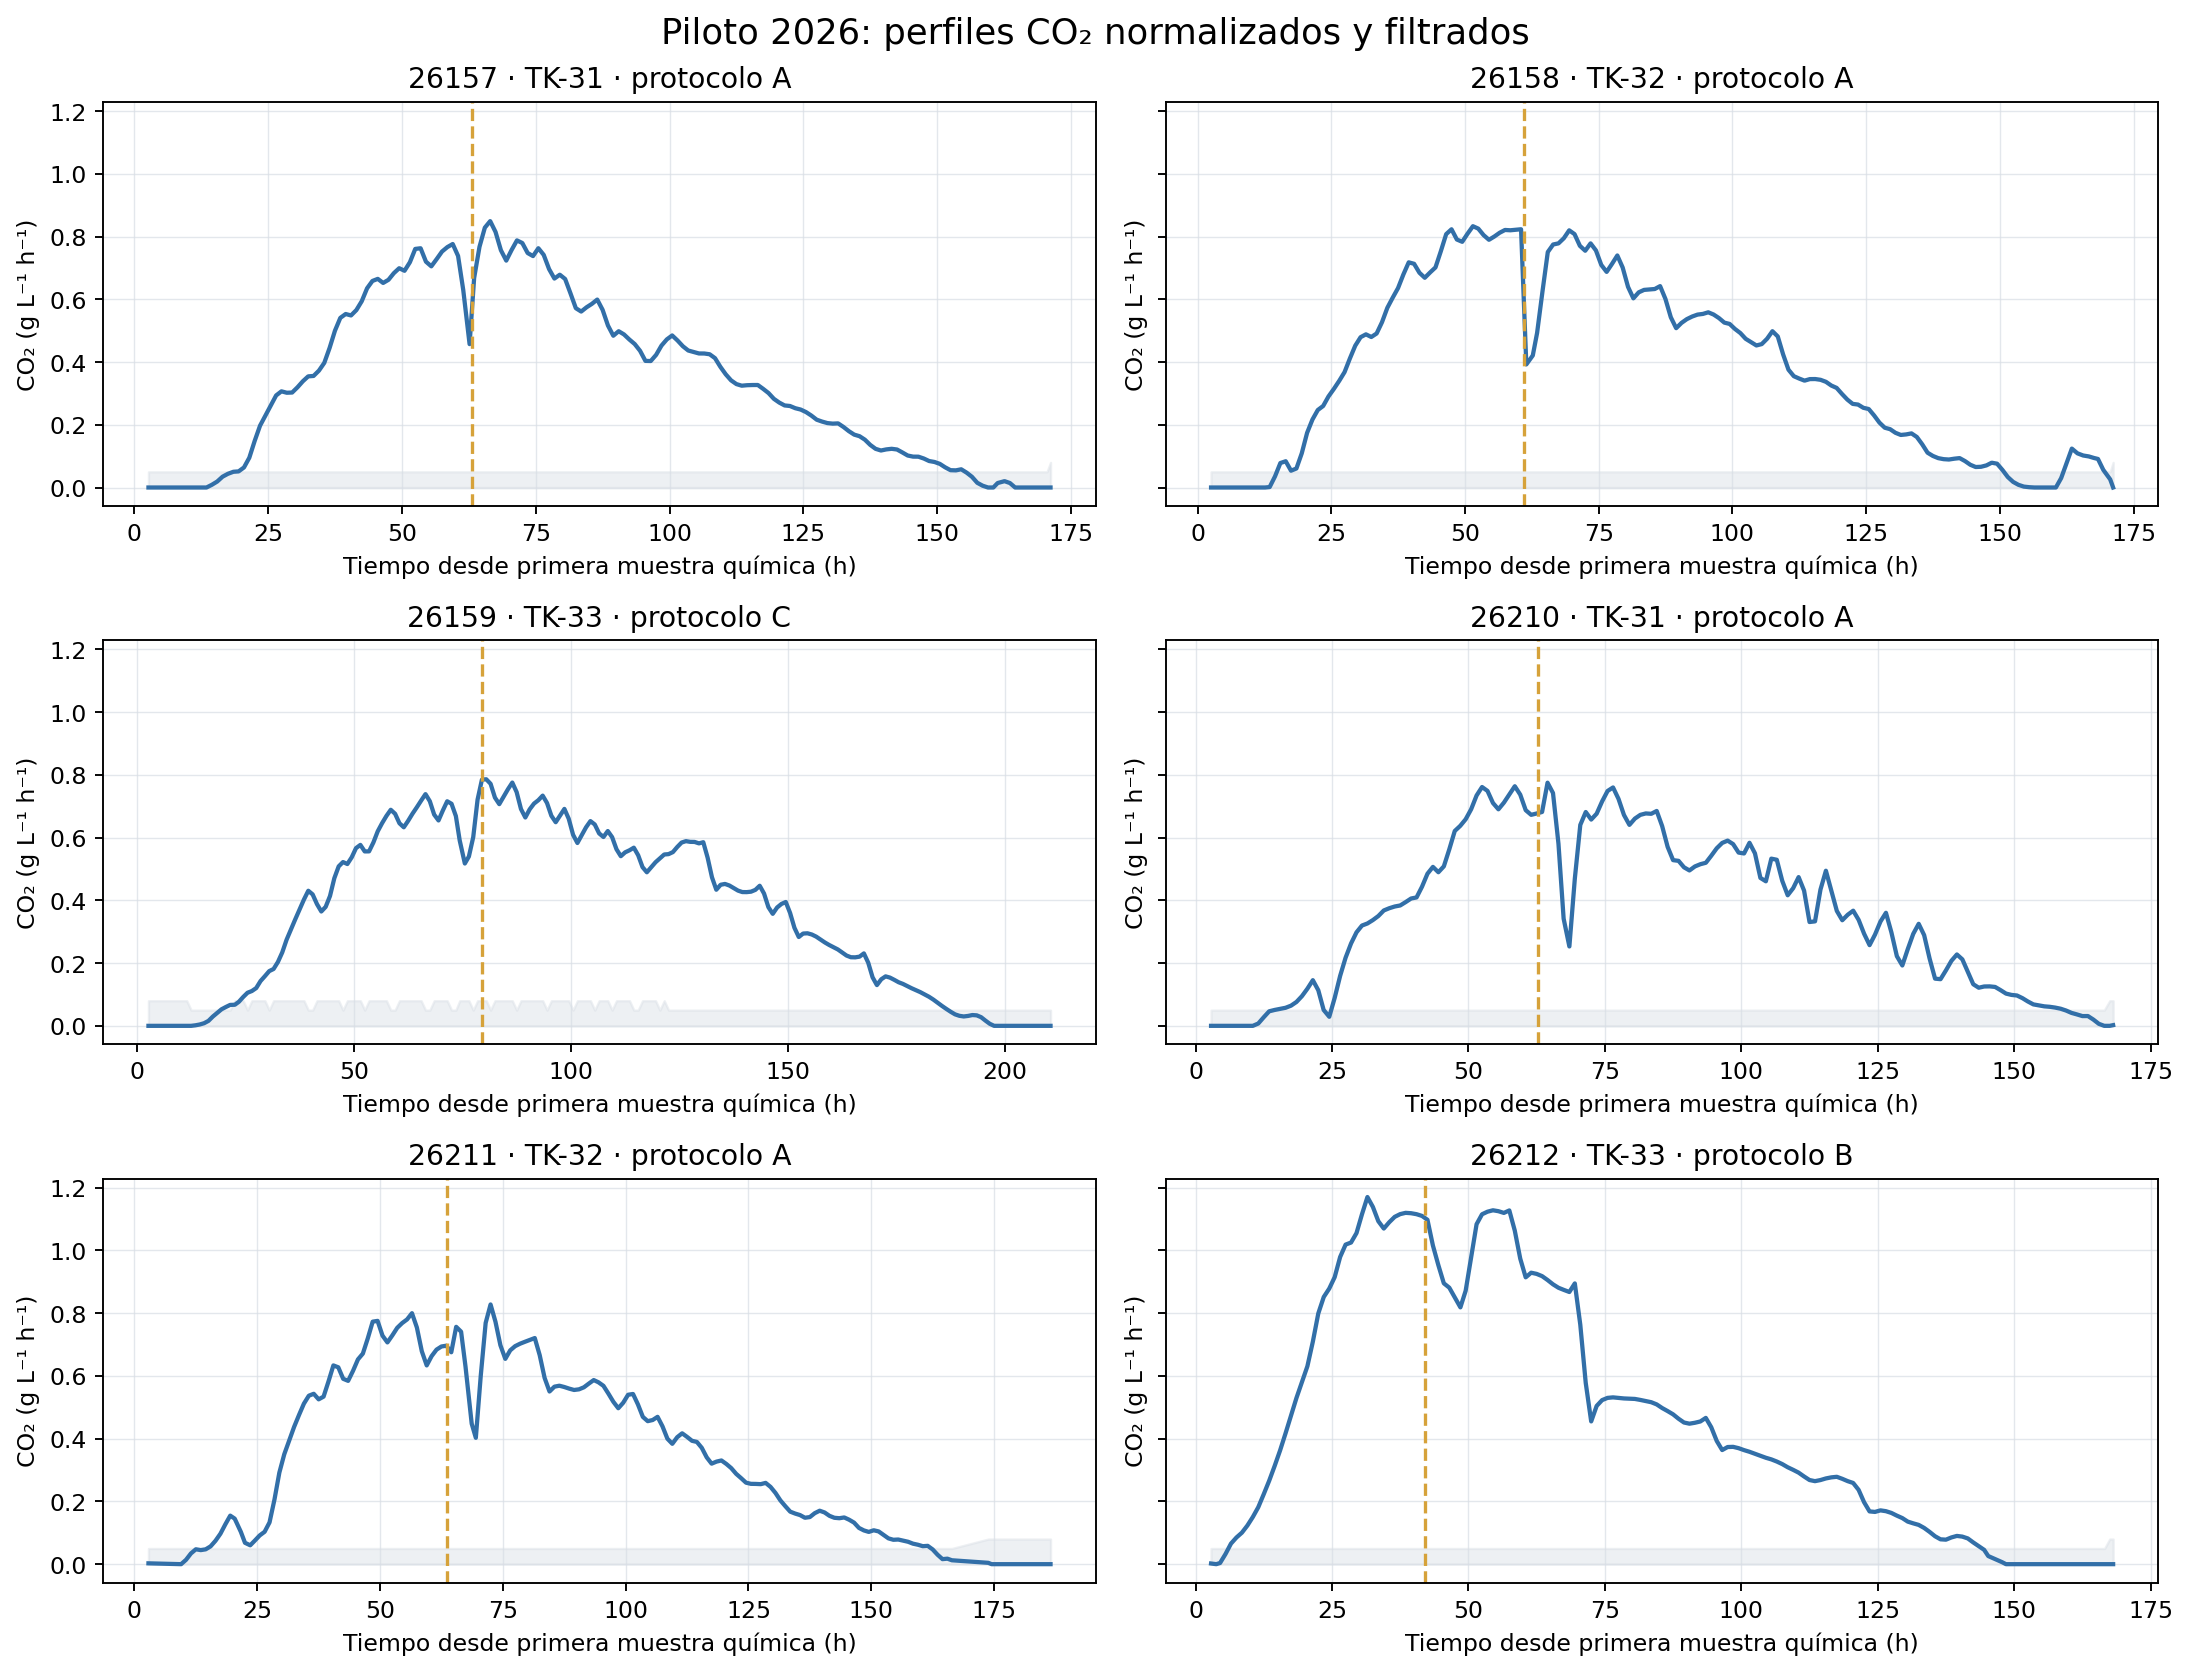

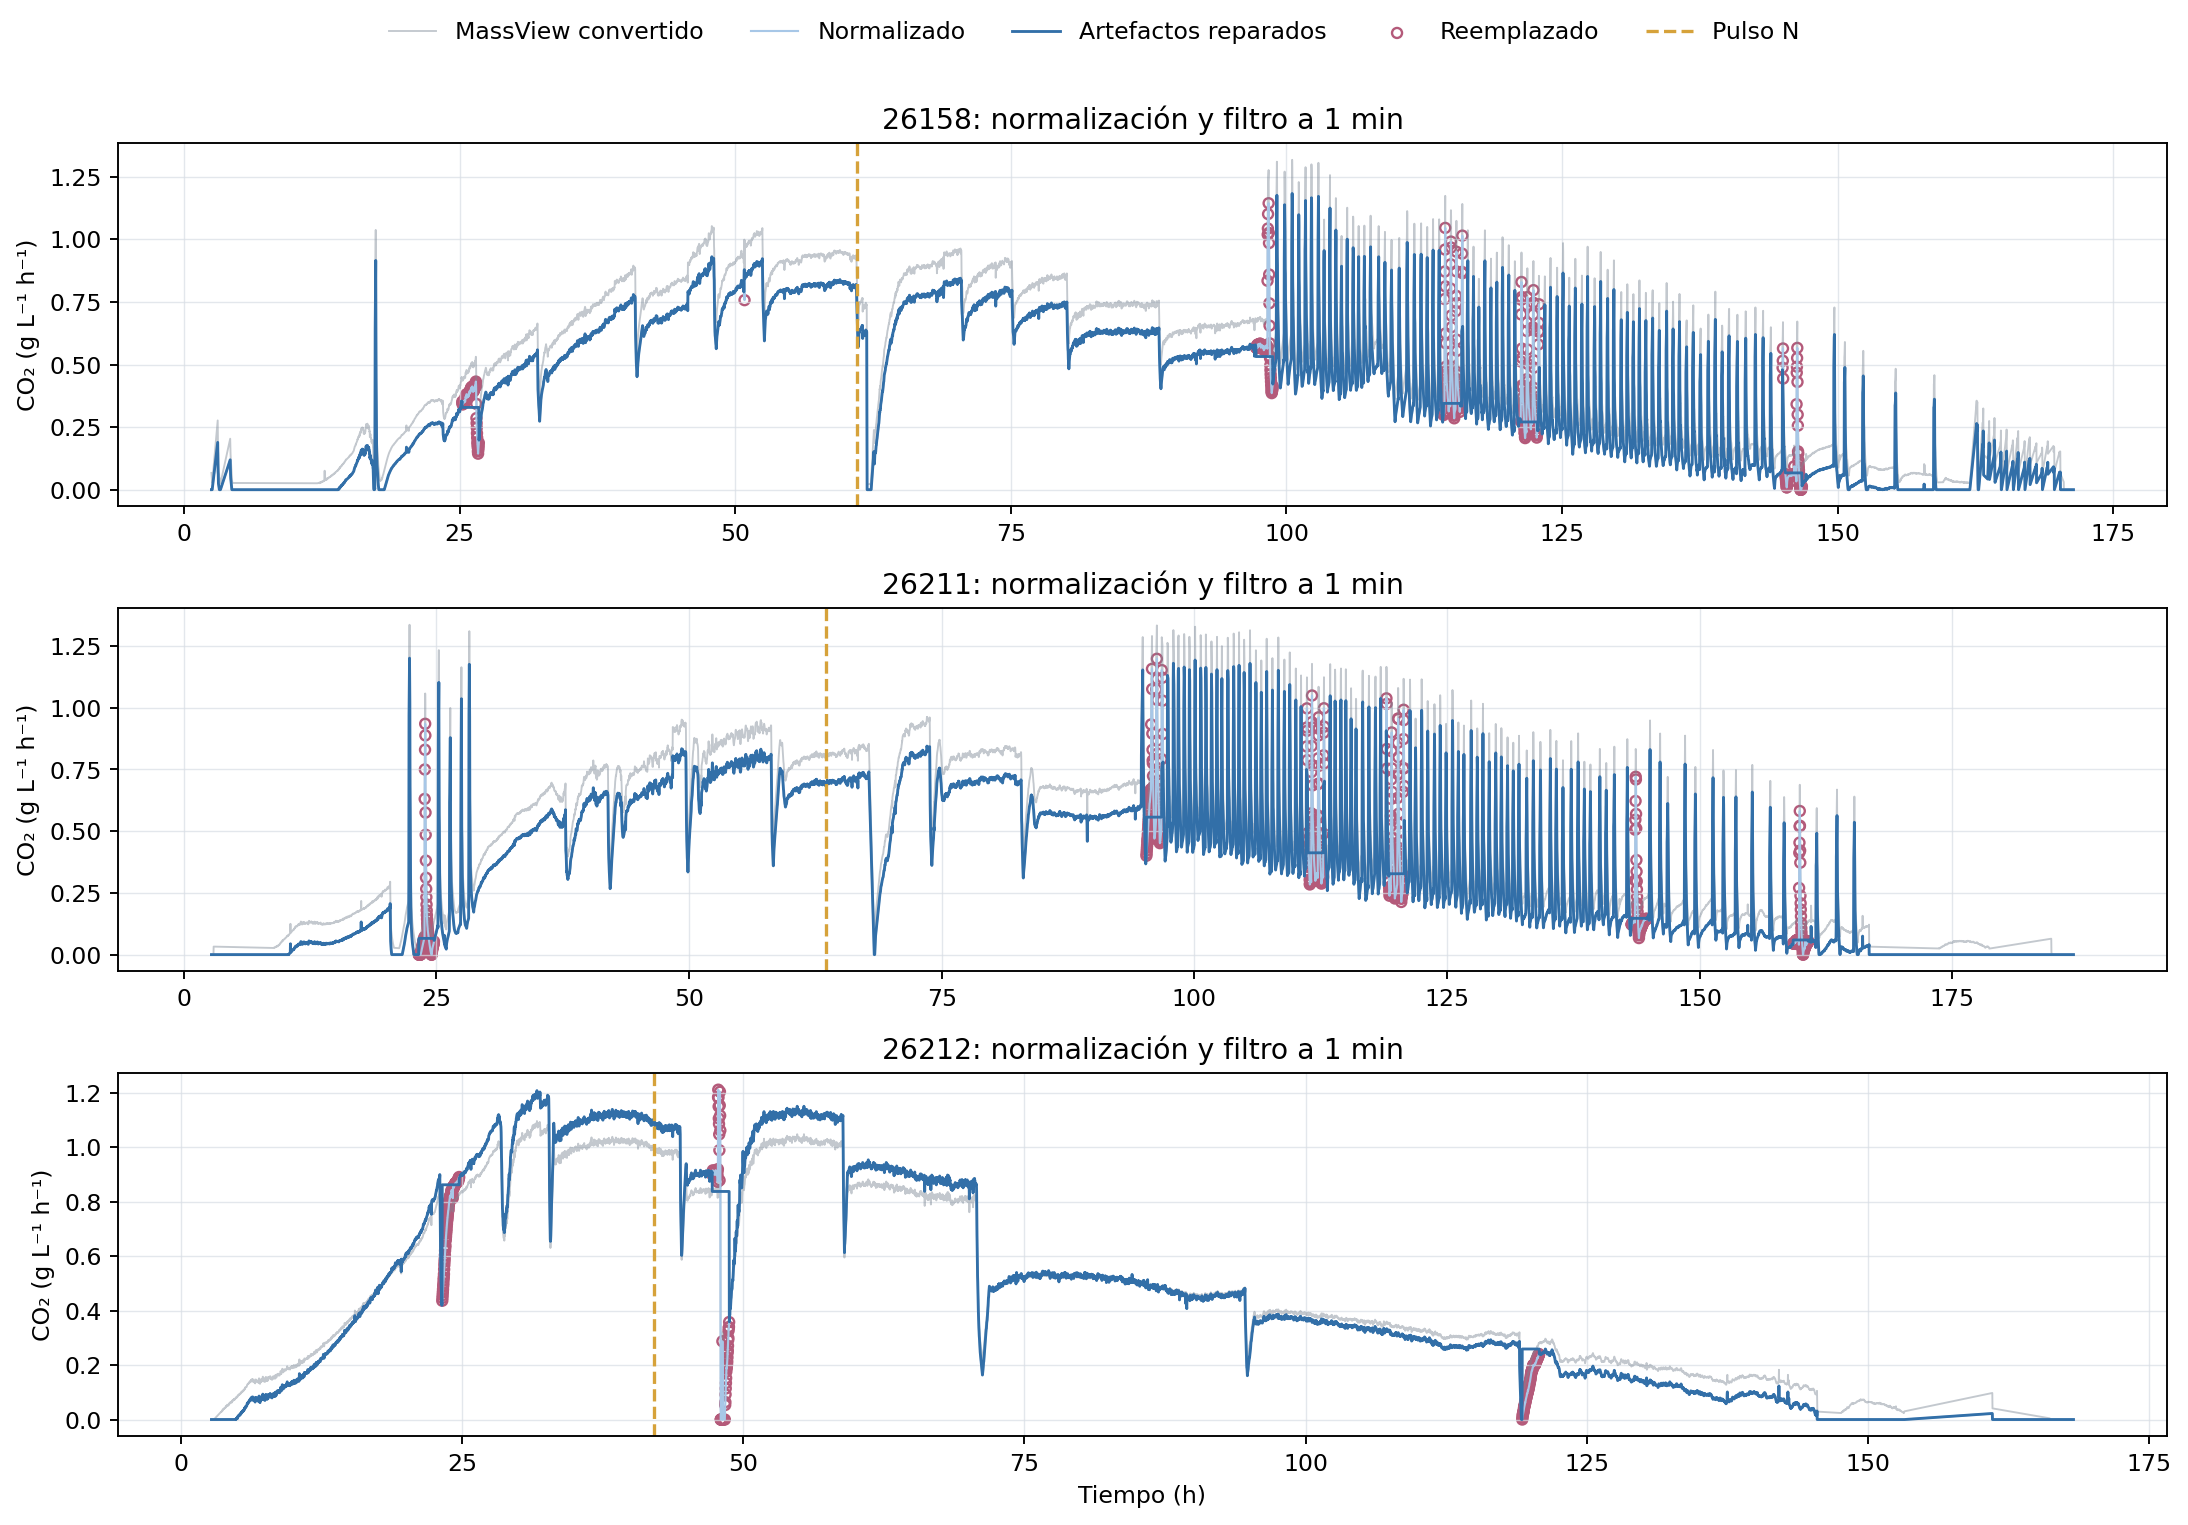

In [3]:
display(Image(filename=analysis.FIGURE_DIR / "co2_data_overview.png"))
display(Image(filename=analysis.FIGURE_DIR / "sensor_normalization_and_filter.png"))

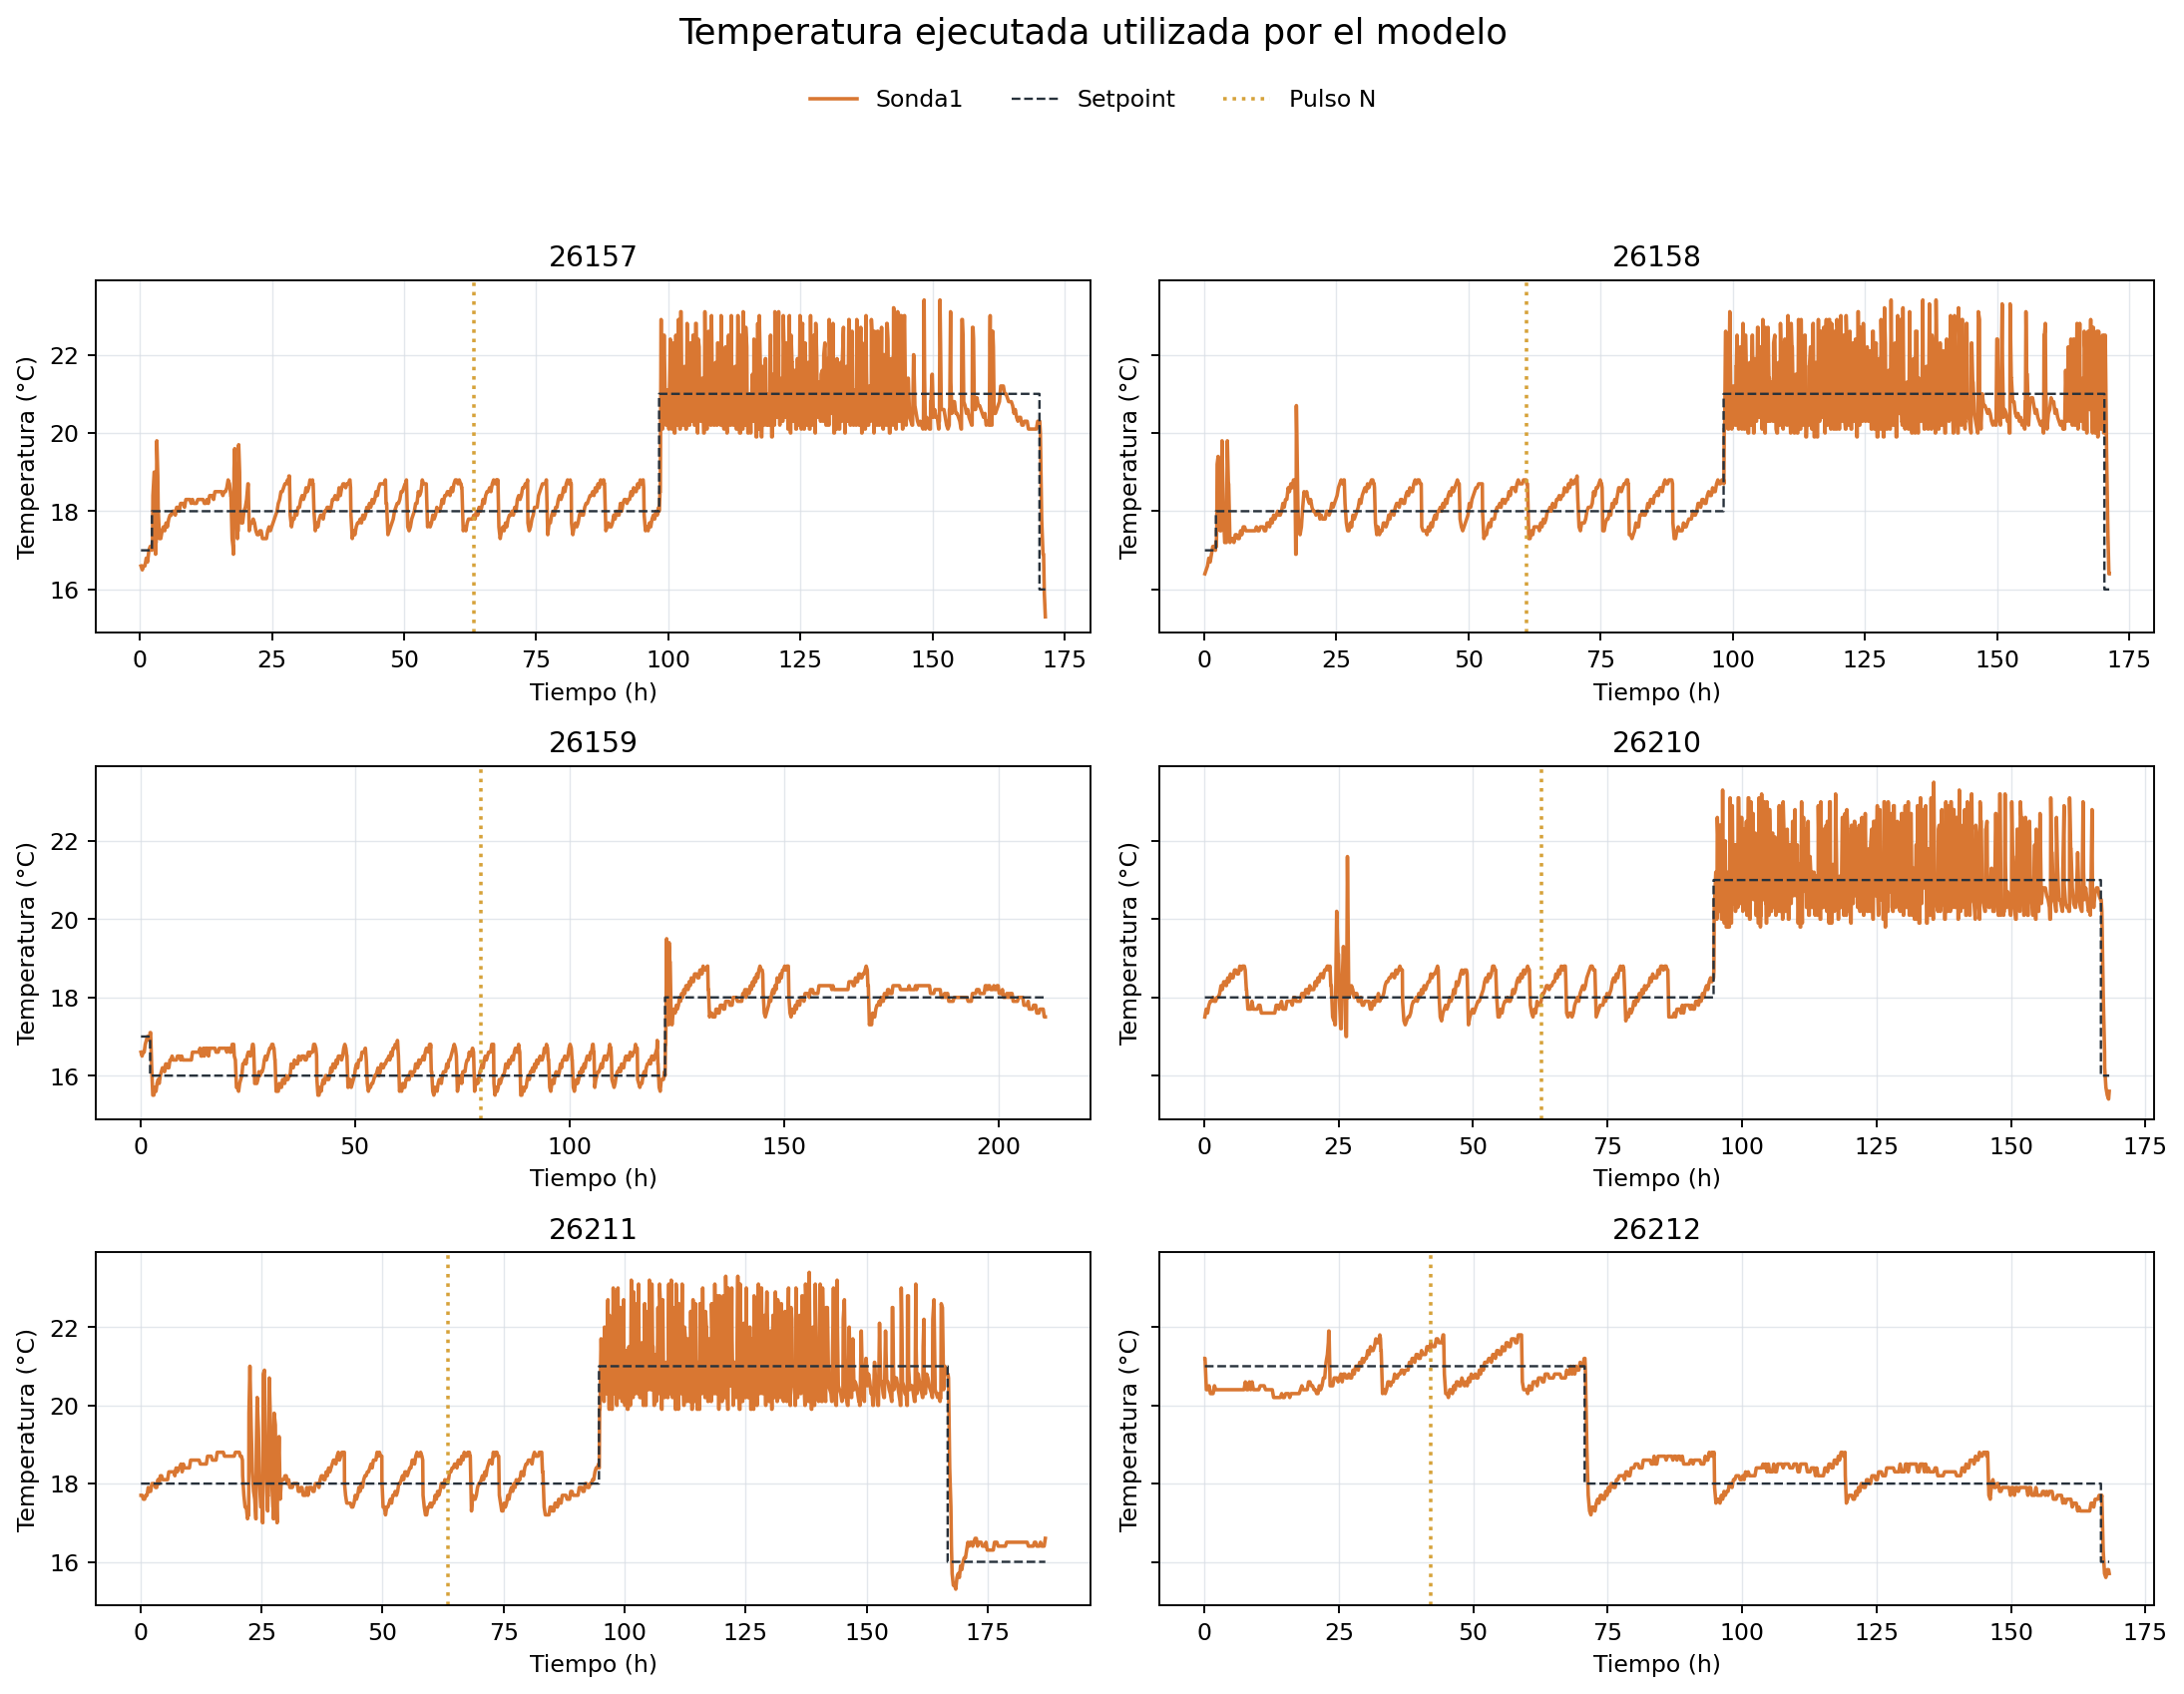

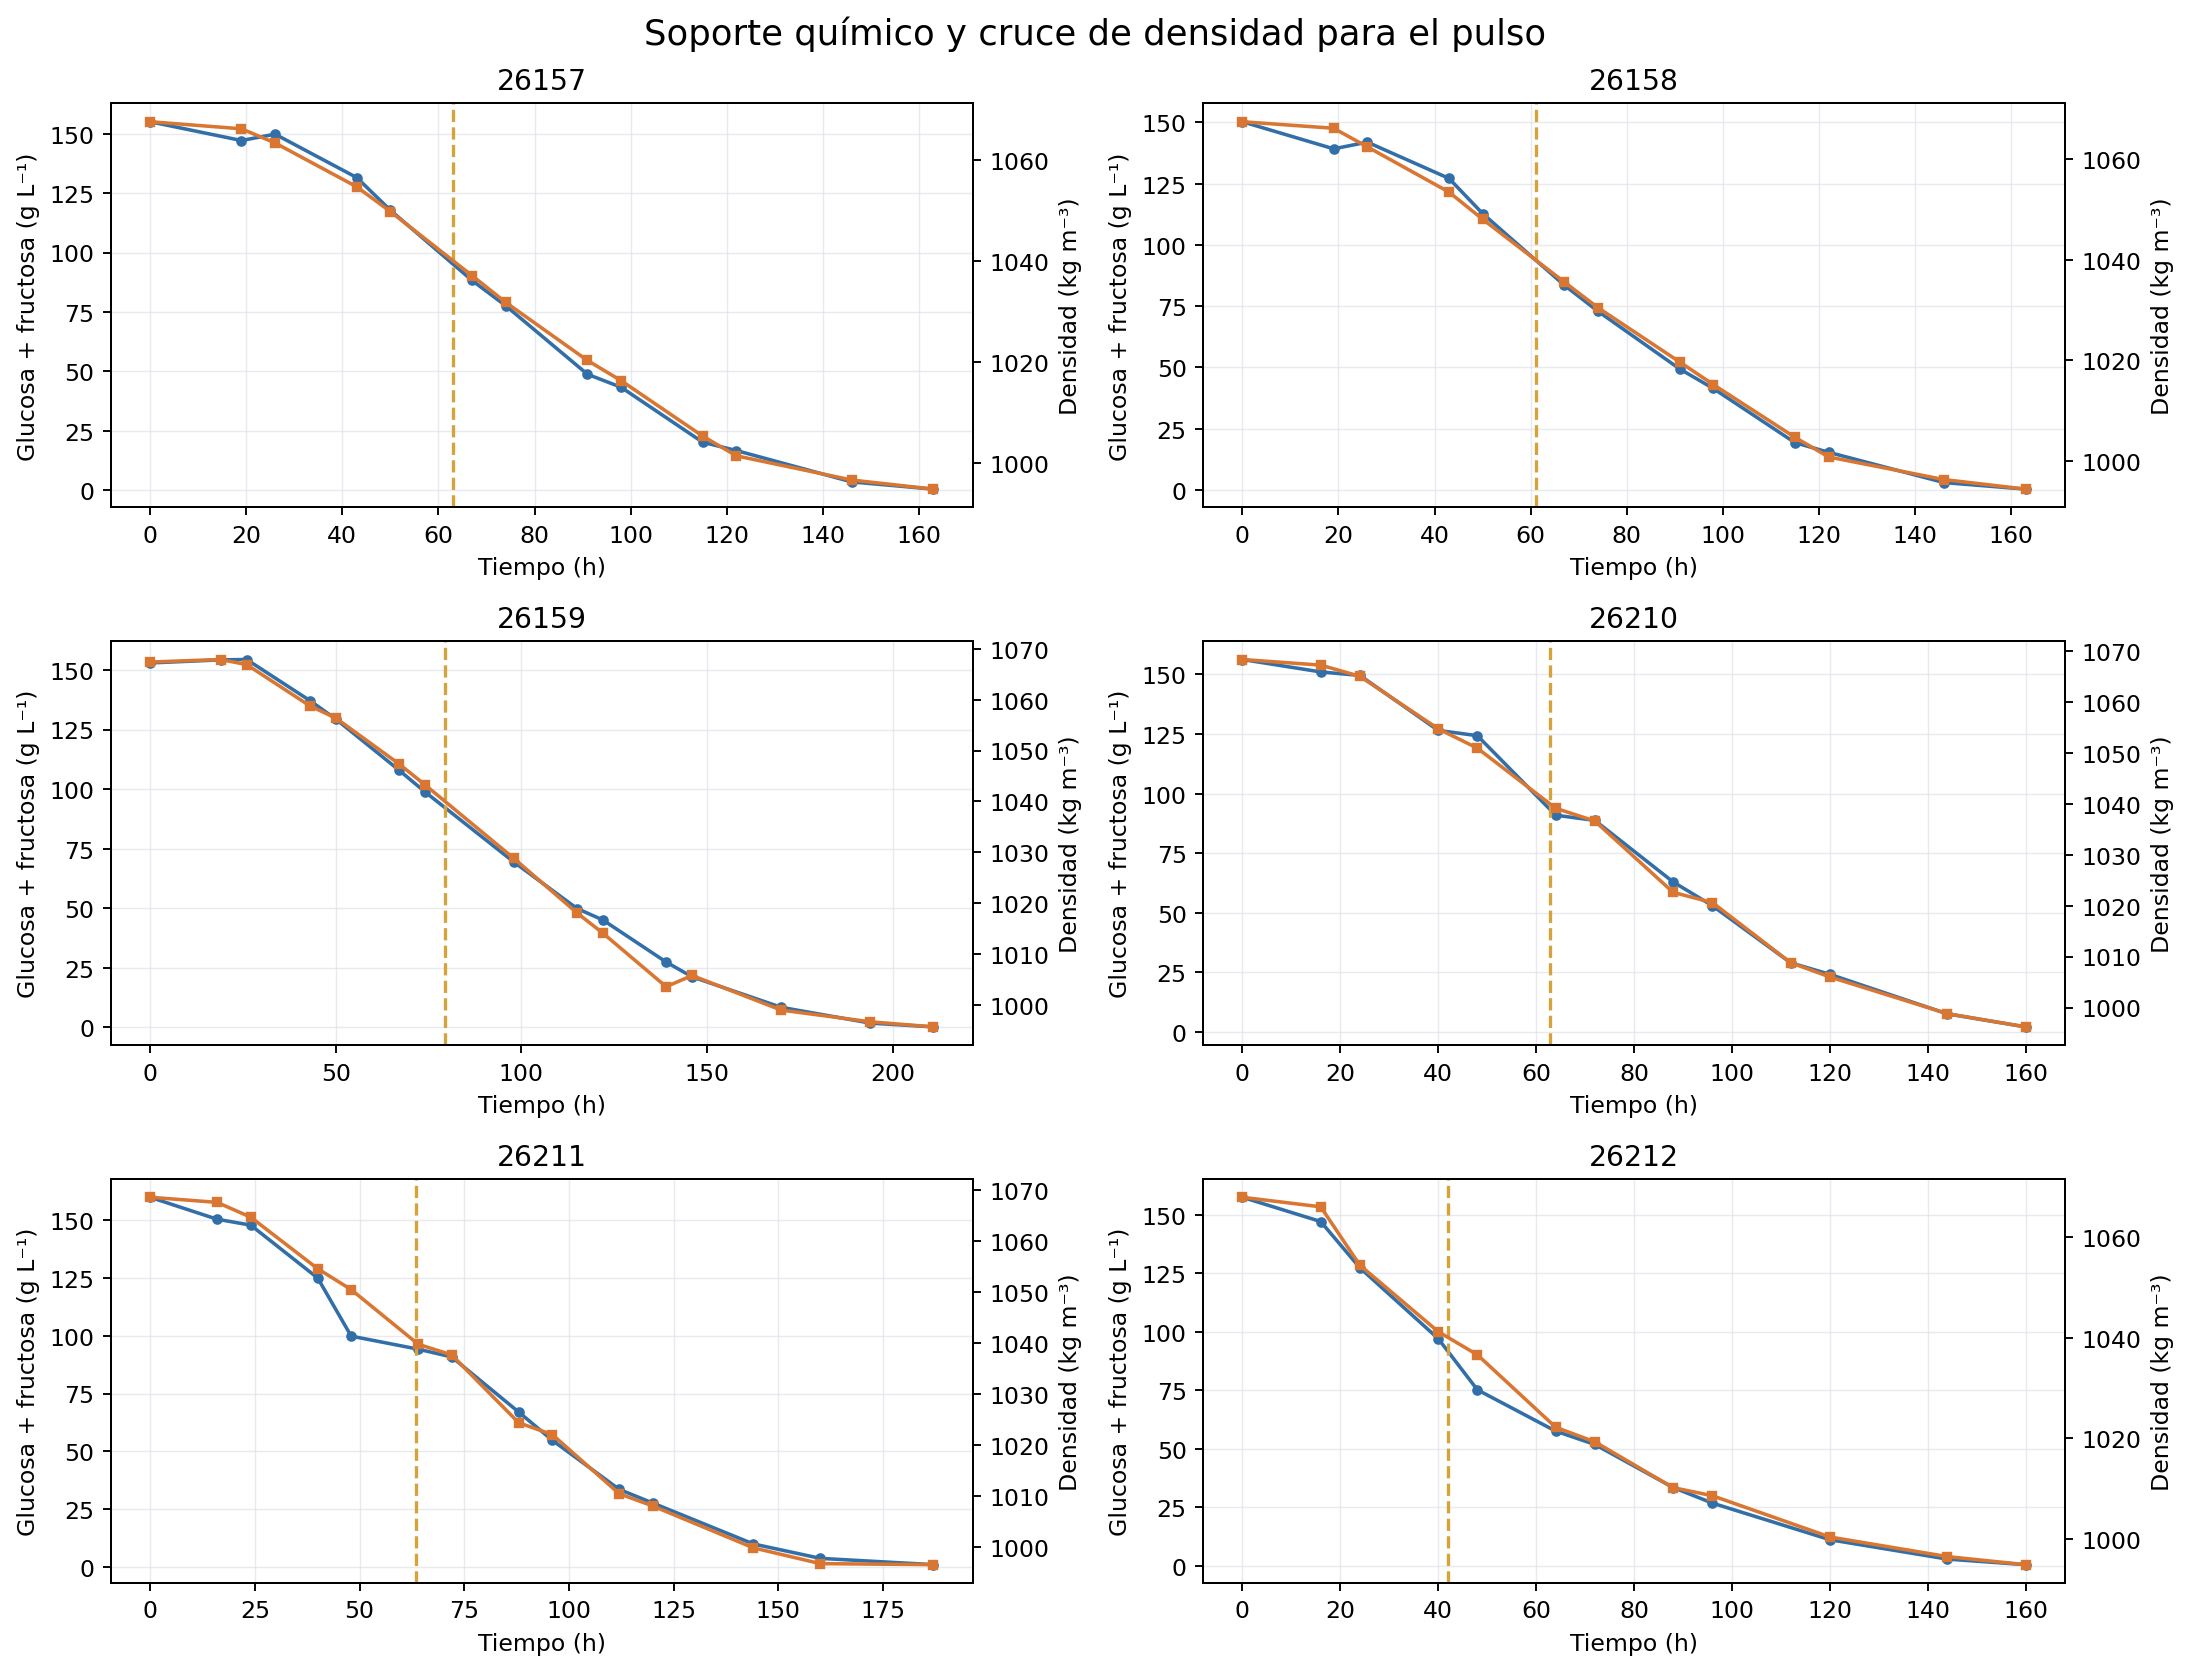

In [4]:
display(Image(filename=analysis.FIGURE_DIR / "temperature_profiles_model_input.png"))
display(Image(filename=analysis.FIGURE_DIR / "chemistry_and_pulse_timeline.png"))

## Resultados de calibración y validación

In [5]:
display(result["fit_parameters"].round(5))
display(result["validation"][[
    "calibration_matrix", "target_matrix", "batch", "role", "rmse_g_l_h",
    "r2", "observed_onset_h", "predicted_onset_h", "onset_delay_h",
    "integral_ratio_pred_over_obs"
]].round(4))

,calibration_matrix,parameter,estimate,lower_bound,upper_bound,active_bound,relative_bound_distance
0,pilot_lot2,kCO2_release_h,0.04613,0.03,25.00,False,0.06399
1,pilot_lot2,CO2sat_scale,0.35000,0.35,2.50,True,0.00000
2,pilot_lot2,O2_qmax_mg_gdw_h,0.15000,0.15,6.00,True,0.00000
3,pilot_lot2,O2_initial_scale,0.14480,0.05,1.50,False,0.31264
4,pilot_lot2,pulse_t_rise_h,72.00000,1.00,72.00,True,0.00000
5,pilot_lot2,pulse_activity_gain,0.37150,0.25,4.00,False,0.14286
6,pilot_lot2,chem_activation_start_fraction,0.01000,0.01,0.95,True,0.00000
7,pilot_lot2,chem_activation_duration_fraction,0.35000,0.35,2.00,True,0.00000
8,pilot_lot2,matrix_gain,2.58983,0.10,20.00,False,0.38581
9,pilot_lot3,kCO2_release_h,25.00000,0.03,25.00,True,0.00000


,calibration_matrix,target_matrix,batch,role,rmse_g_l_h,r2,observed_onset_h,predicted_onset_h,onset_delay_h,integral_ratio_pred_over_obs
0,pilot_lot3,pilot_lot2,26158,cross_holdout,0.1790,0.5096,18.9609,6.7550,-12.2058,1.0303
1,pilot_lot2,pilot_lot2,26158,internal_holdout,0.0980,0.8531,18.9609,23.2806,4.3198,1.0075
2,pilot_lot2,pilot_lot3,26211,cross_holdout,0.2626,-0.2142,16.9650,46.5544,29.5895,0.9367
3,pilot_lot3,pilot_lot3,26211,internal_holdout,0.1335,0.6859,16.9650,29.3532,12.3883,1.0332


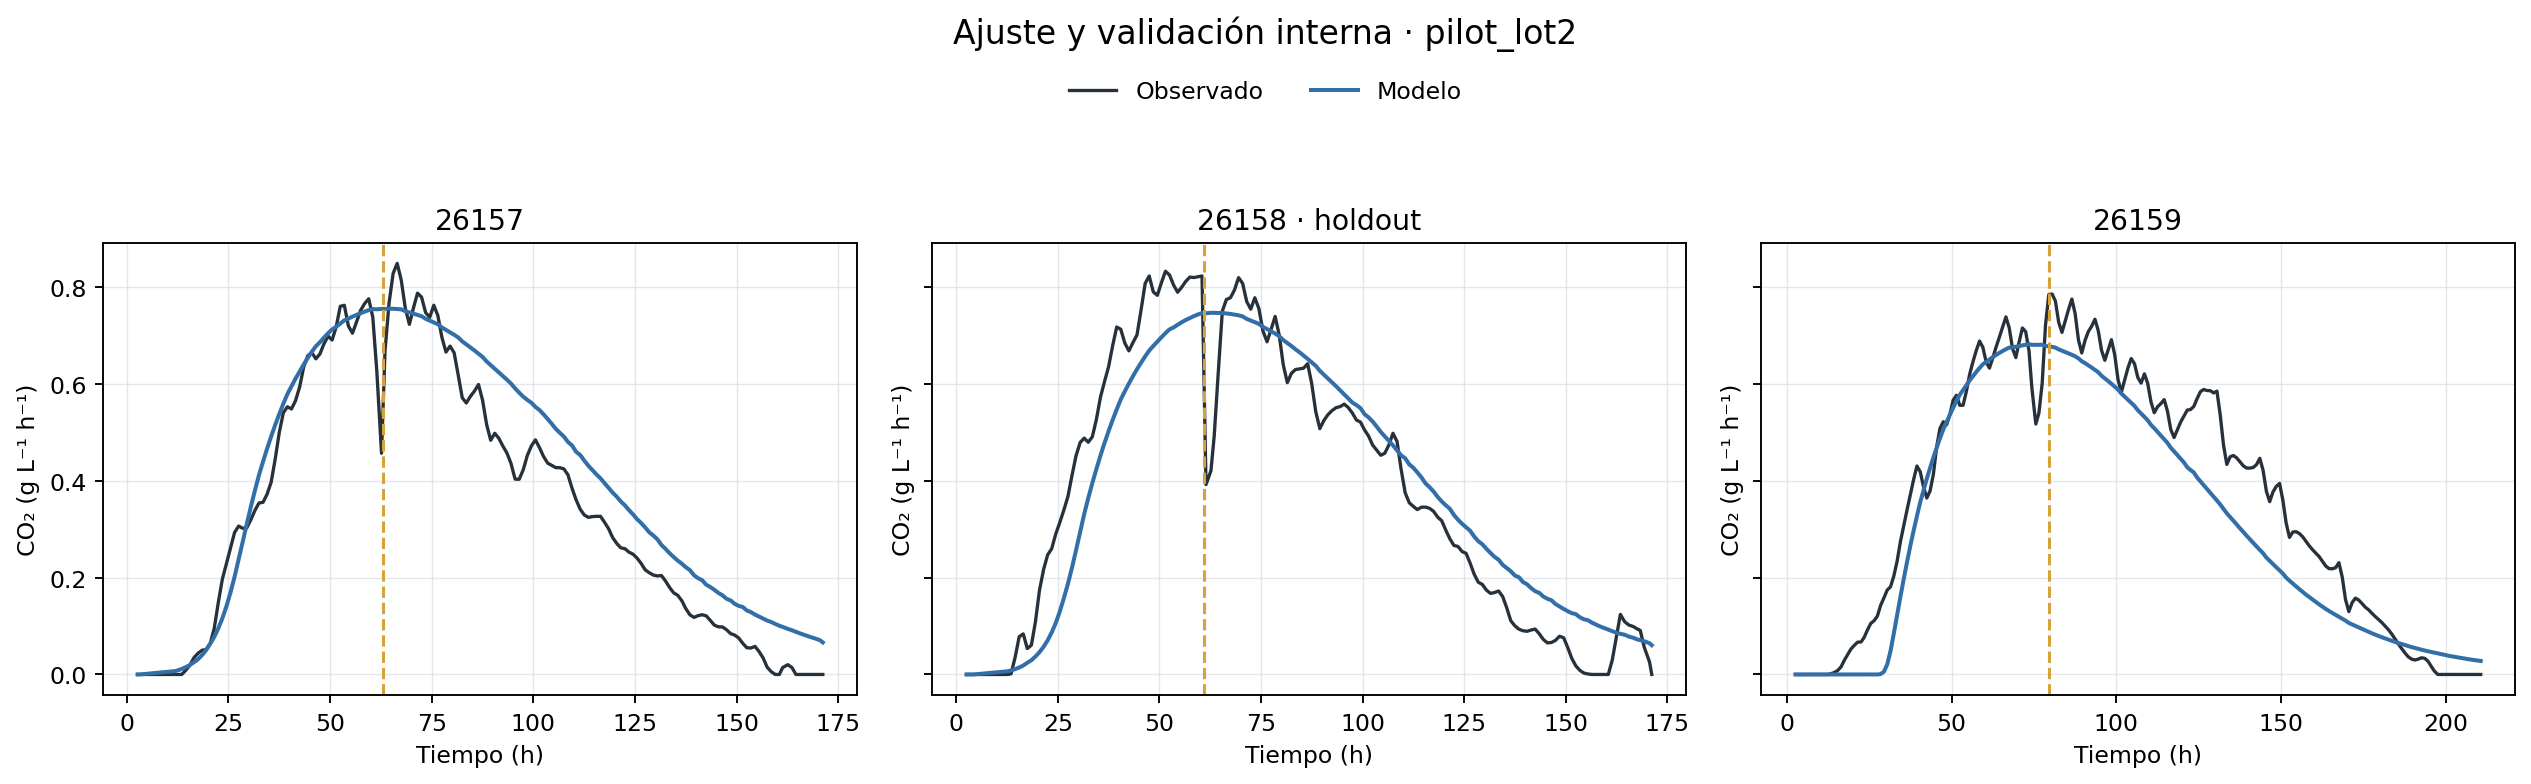

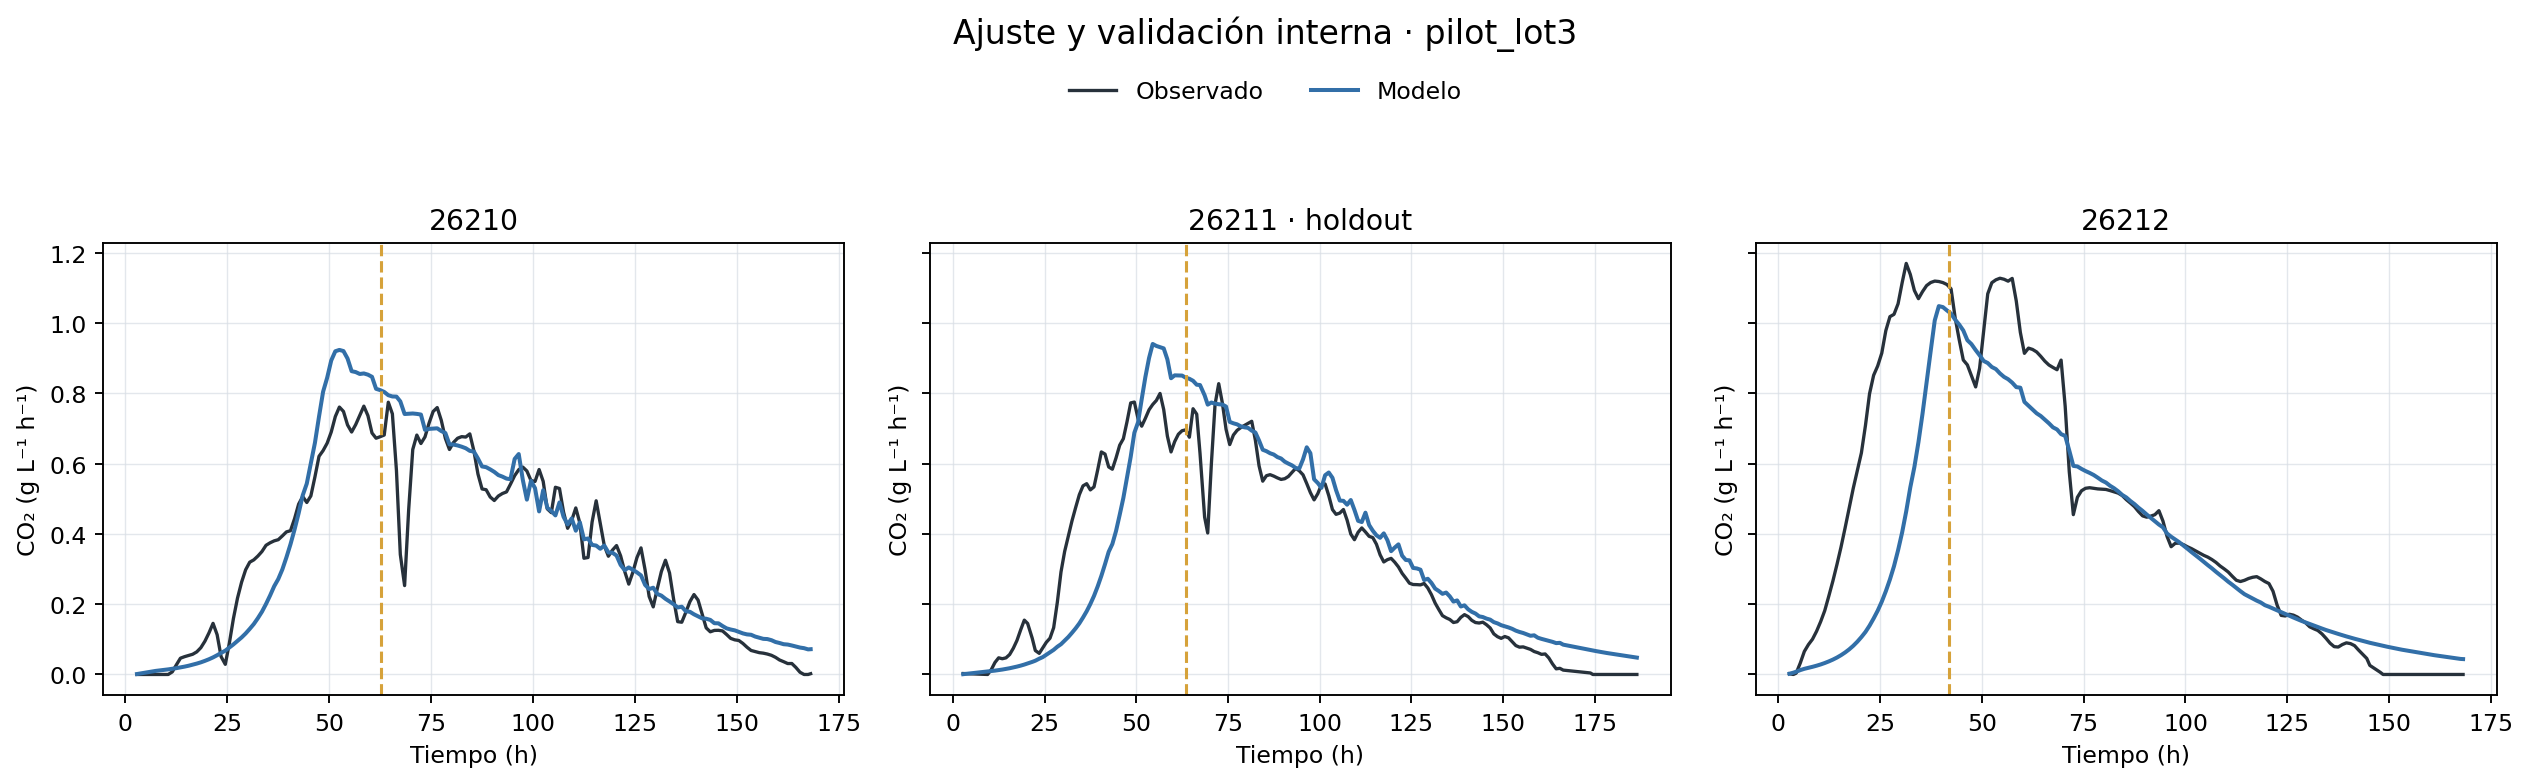

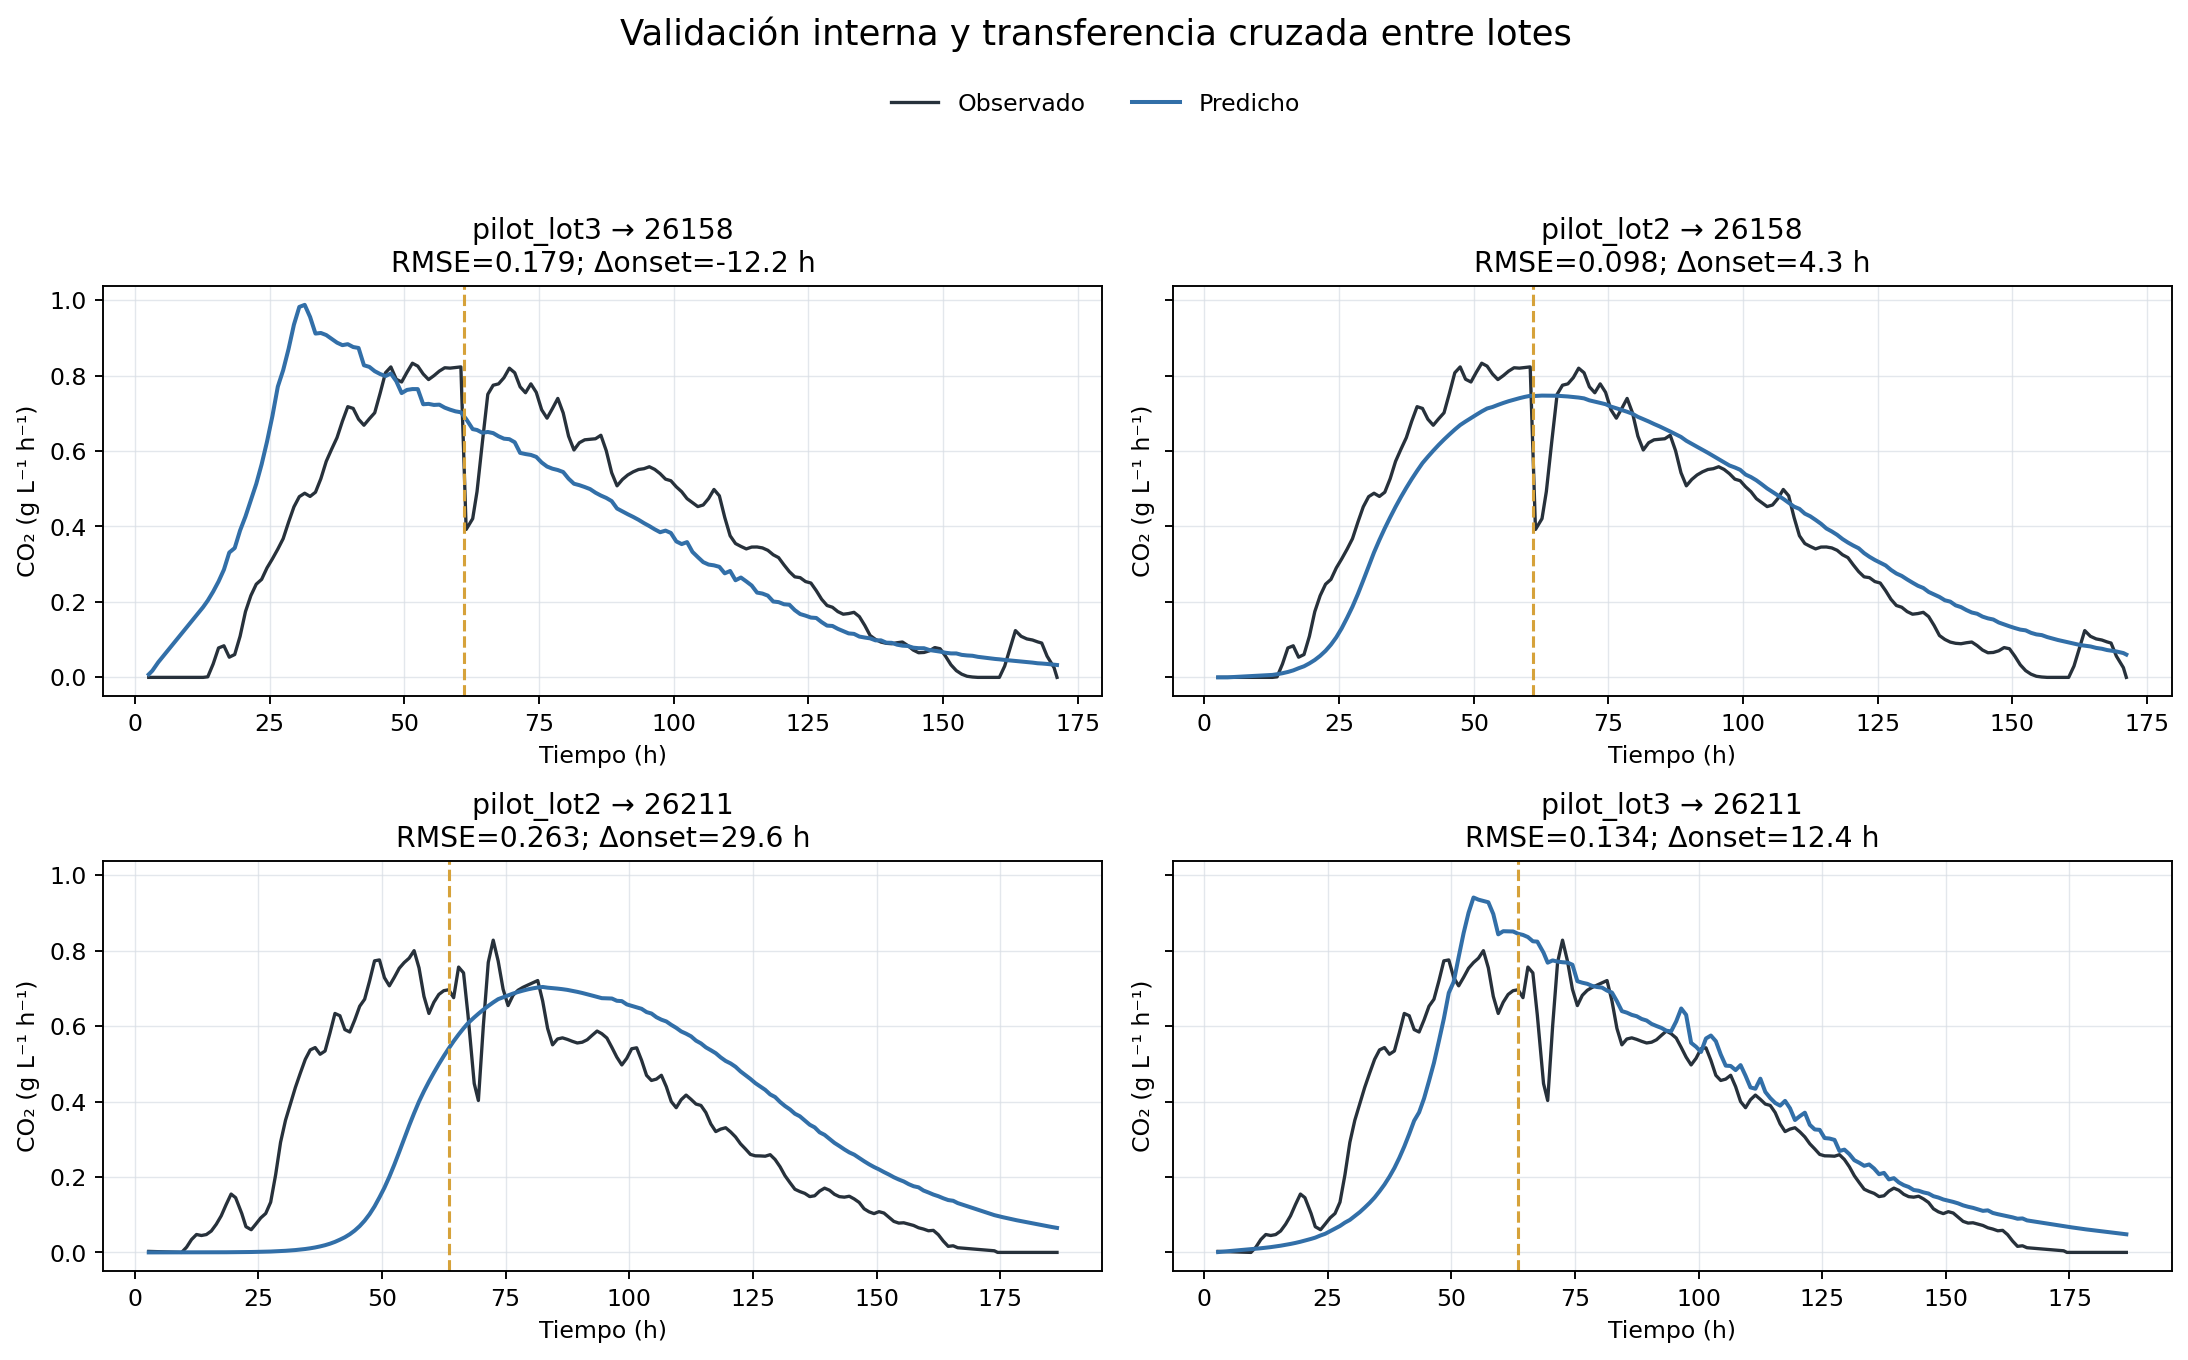

In [6]:
display(Image(filename=analysis.FIGURE_DIR / "calibration_overlays_pilot_lot2.png"))
display(Image(filename=analysis.FIGURE_DIR / "calibration_overlays_pilot_lot3.png"))
display(Image(filename=analysis.FIGURE_DIR / "heldout_cross_lot_validation.png"))

,model,calibration_matrix,target_matrix,batch,role,rmse_g_l_h,onset_delay_h
1,solubility_o2_nitrogen_boost_continuous_release,pilot_lot2,pilot_lot2,26158,internal_holdout,0.0980,4.3198
5,solubility_o2_nitrogen_boost_threshold_release,pilot_lot2,pilot_lot2,26158,internal_holdout,0.0903,5.2205
9,solubility_o2_slow_transition,pilot_lot2,pilot_lot2,26158,internal_holdout,0.2736,16.2047
0,solubility_o2_nitrogen_boost_continuous_release,pilot_lot3,pilot_lot2,26158,cross_holdout,0.1790,-12.2058
4,solubility_o2_nitrogen_boost_threshold_release,pilot_lot3,pilot_lot2,26158,cross_holdout,0.1704,-2.3228
8,solubility_o2_slow_transition,pilot_lot3,pilot_lot2,26158,cross_holdout,0.2860,18.8750
2,solubility_o2_nitrogen_boost_continuous_release,pilot_lot2,pilot_lot3,26211,cross_holdout,0.2626,29.5895
6,solubility_o2_nitrogen_boost_threshold_release,pilot_lot2,pilot_lot3,26211,cross_holdout,0.2751,30.1452
10,solubility_o2_slow_transition,pilot_lot2,pilot_lot3,26211,cross_holdout,0.3889,42.9572
3,solubility_o2_nitrogen_boost_continuous_release,pilot_lot3,pilot_lot3,26211,internal_holdout,0.1335,12.3883


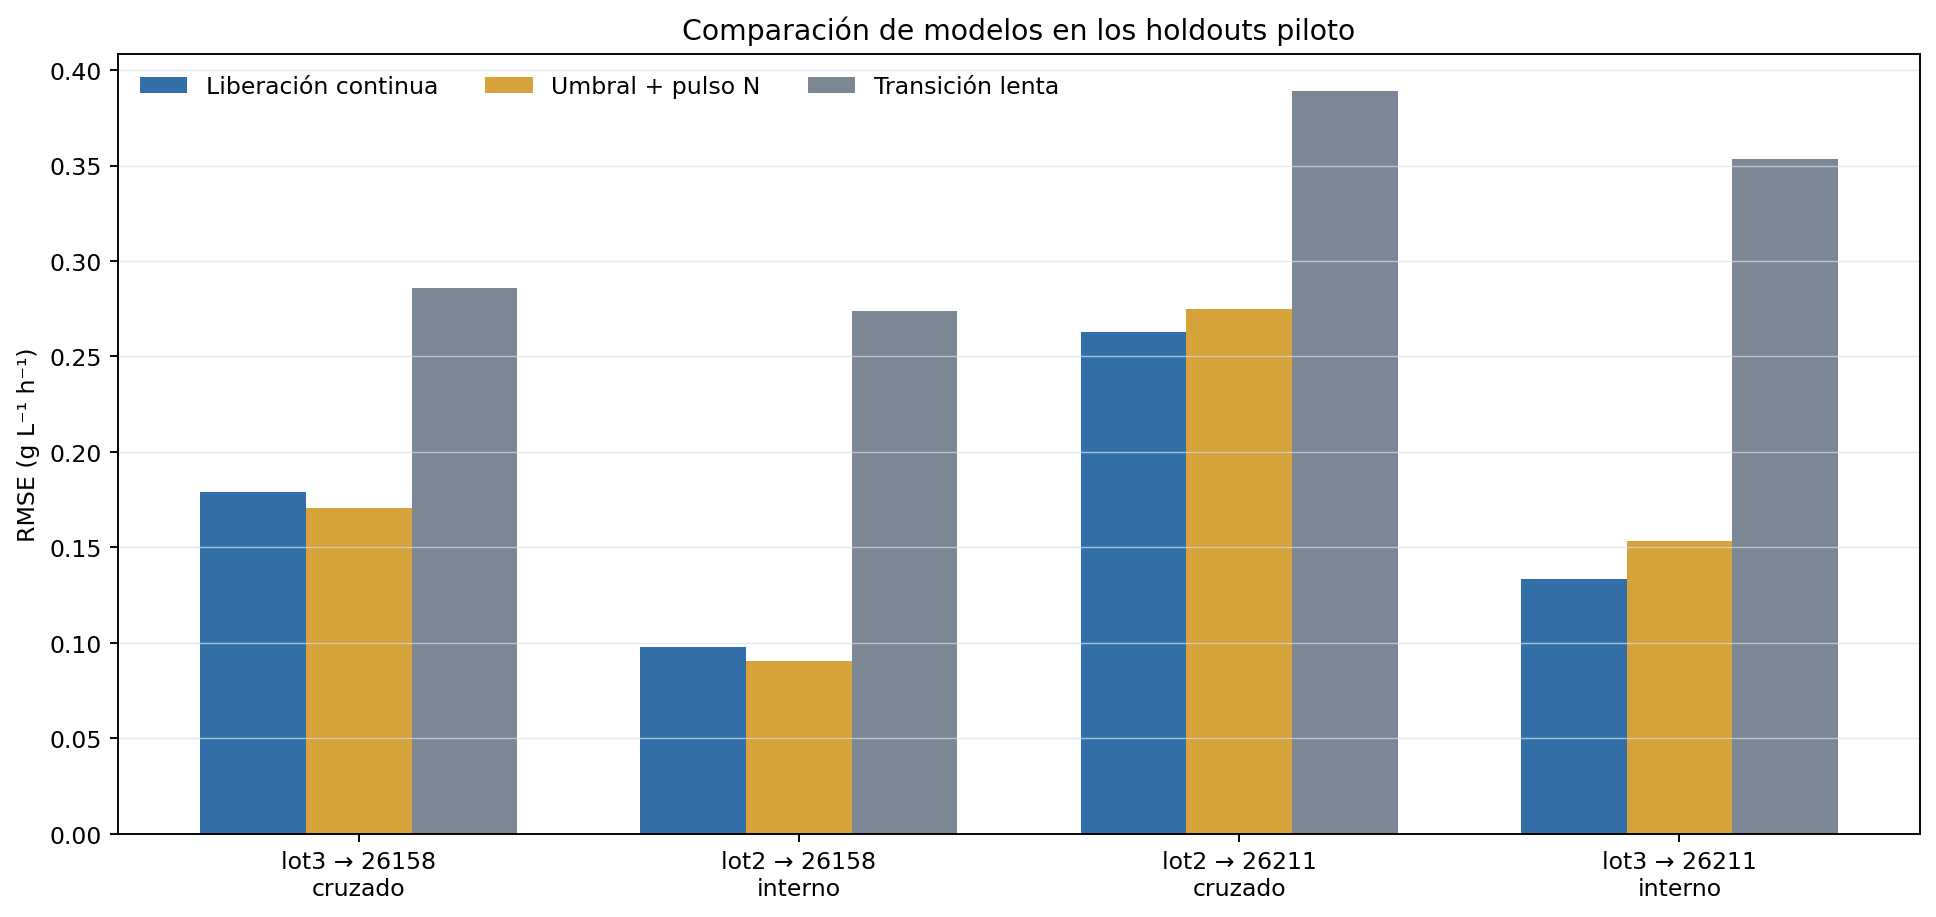

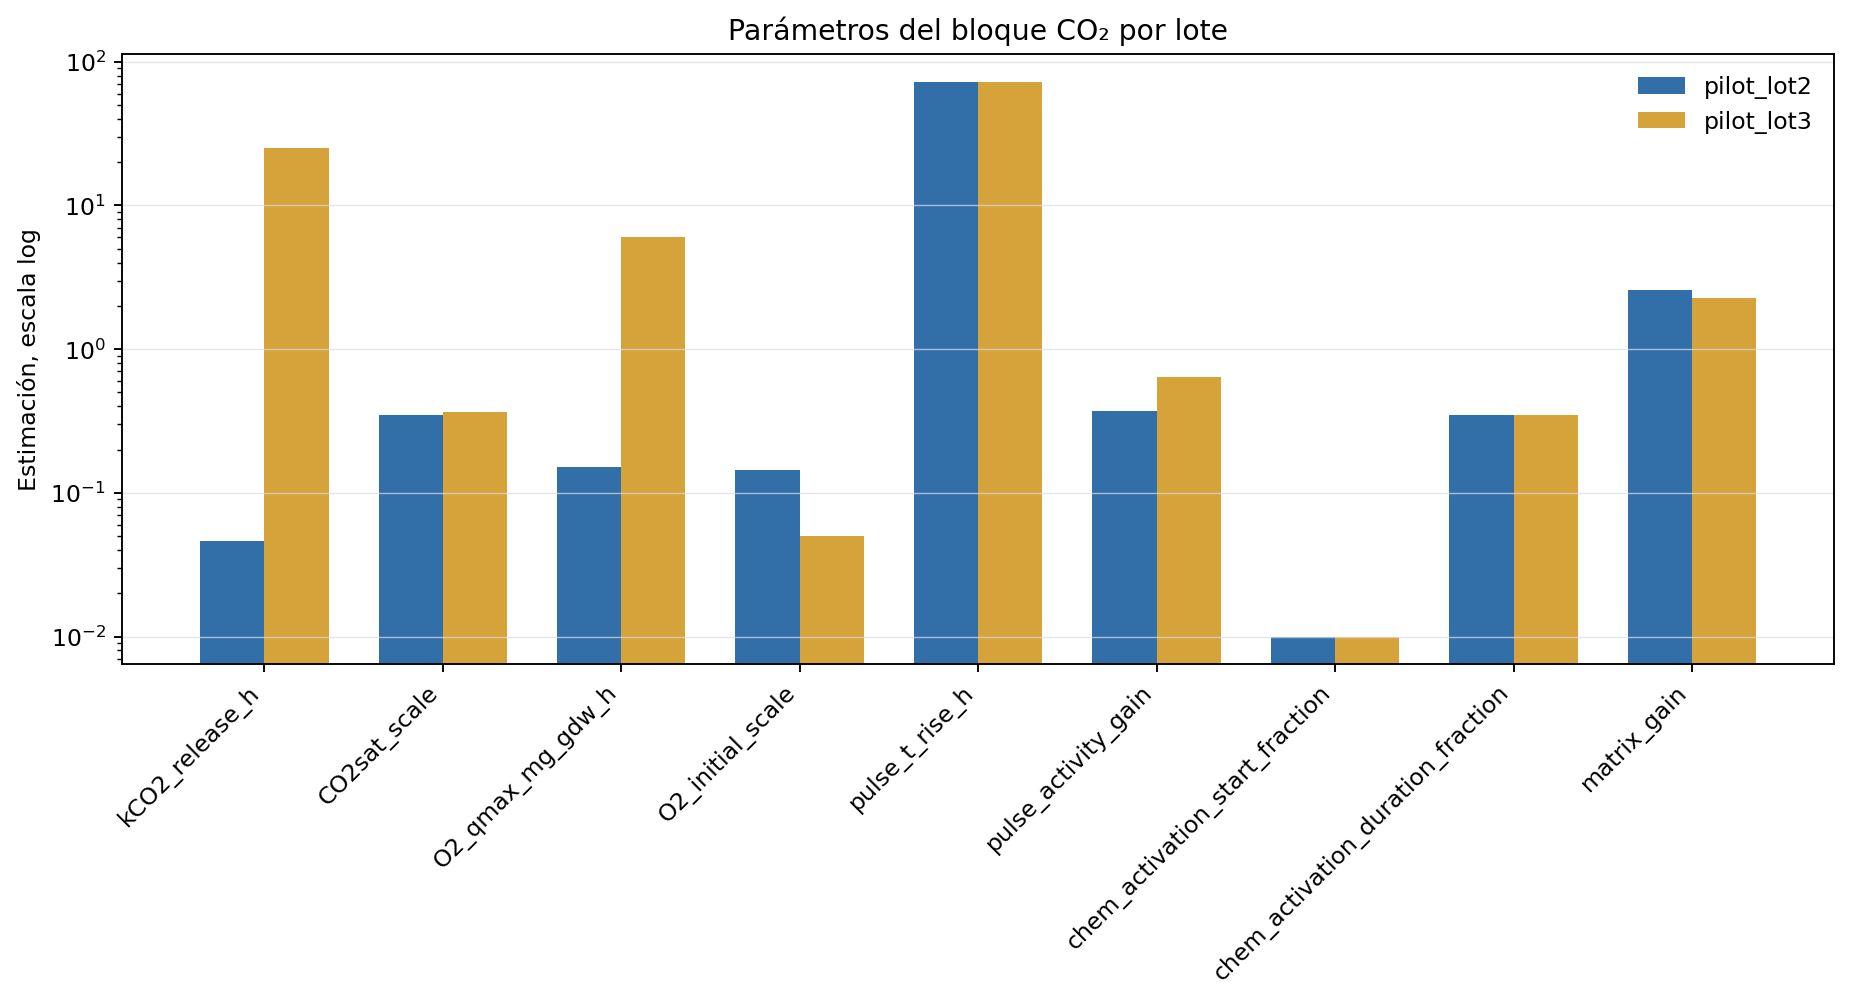

In [7]:
display(result["model_validation"][[
    "model", "calibration_matrix", "target_matrix", "batch", "role", "rmse_g_l_h", "onset_delay_h"
]].round(4))
display(Image(filename=analysis.FIGURE_DIR / "heldout_model_comparison.png"))
display(Image(filename=analysis.FIGURE_DIR / "parameter_comparison.png"))

## Identificabilidad práctica

,matrix,n_residuals,n_shape_parameters,effective_rank,condition_number_log_parameter_jacobian,smallest_singular_value,largest_singular_value,residual_variance_scale,interpretation
0,pilot_lot2,367,8,8,3.383530e+03,0.00084,2.84269,0.00721,moderate_or_better
1,pilot_lot3,321,8,8,3.919989e+11,0.00000,2.03175,0.02624,ill_conditioned


,matrix,parameter,full_fit_estimate,loo_min,loo_median,loo_max,loo_range,loo_relative_range_to_full,n_omissions,n_at_lower_bound,n_at_upper_bound
0,pilot_lot2,chem_activation_start_fraction,0.01,0.01,0.02840,0.04679,0.03679,3.67936,2,1,0
1,pilot_lot2,chem_activation_duration_fraction,0.35,0.35,0.49062,0.63124,0.28124,0.80353,2,1,0
2,pilot_lot3,chem_activation_start_fraction,0.01,0.01,0.01000,0.01000,0.00000,0.00000,2,2,0
3,pilot_lot3,chem_activation_duration_fraction,0.35,0.35,0.35000,0.35000,0.00000,0.00000,2,2,0


,matrix,parameter_1,parameter_2,local_log_parameter_correlation,log_parameter_standard_error_1
55,pilot_lot2,chem_activation_start_fraction,chem_activation_duration_fraction,-0.98985,100.92652
119,pilot_lot3,chem_activation_start_fraction,chem_activation_duration_fraction,1.00000,13.90620


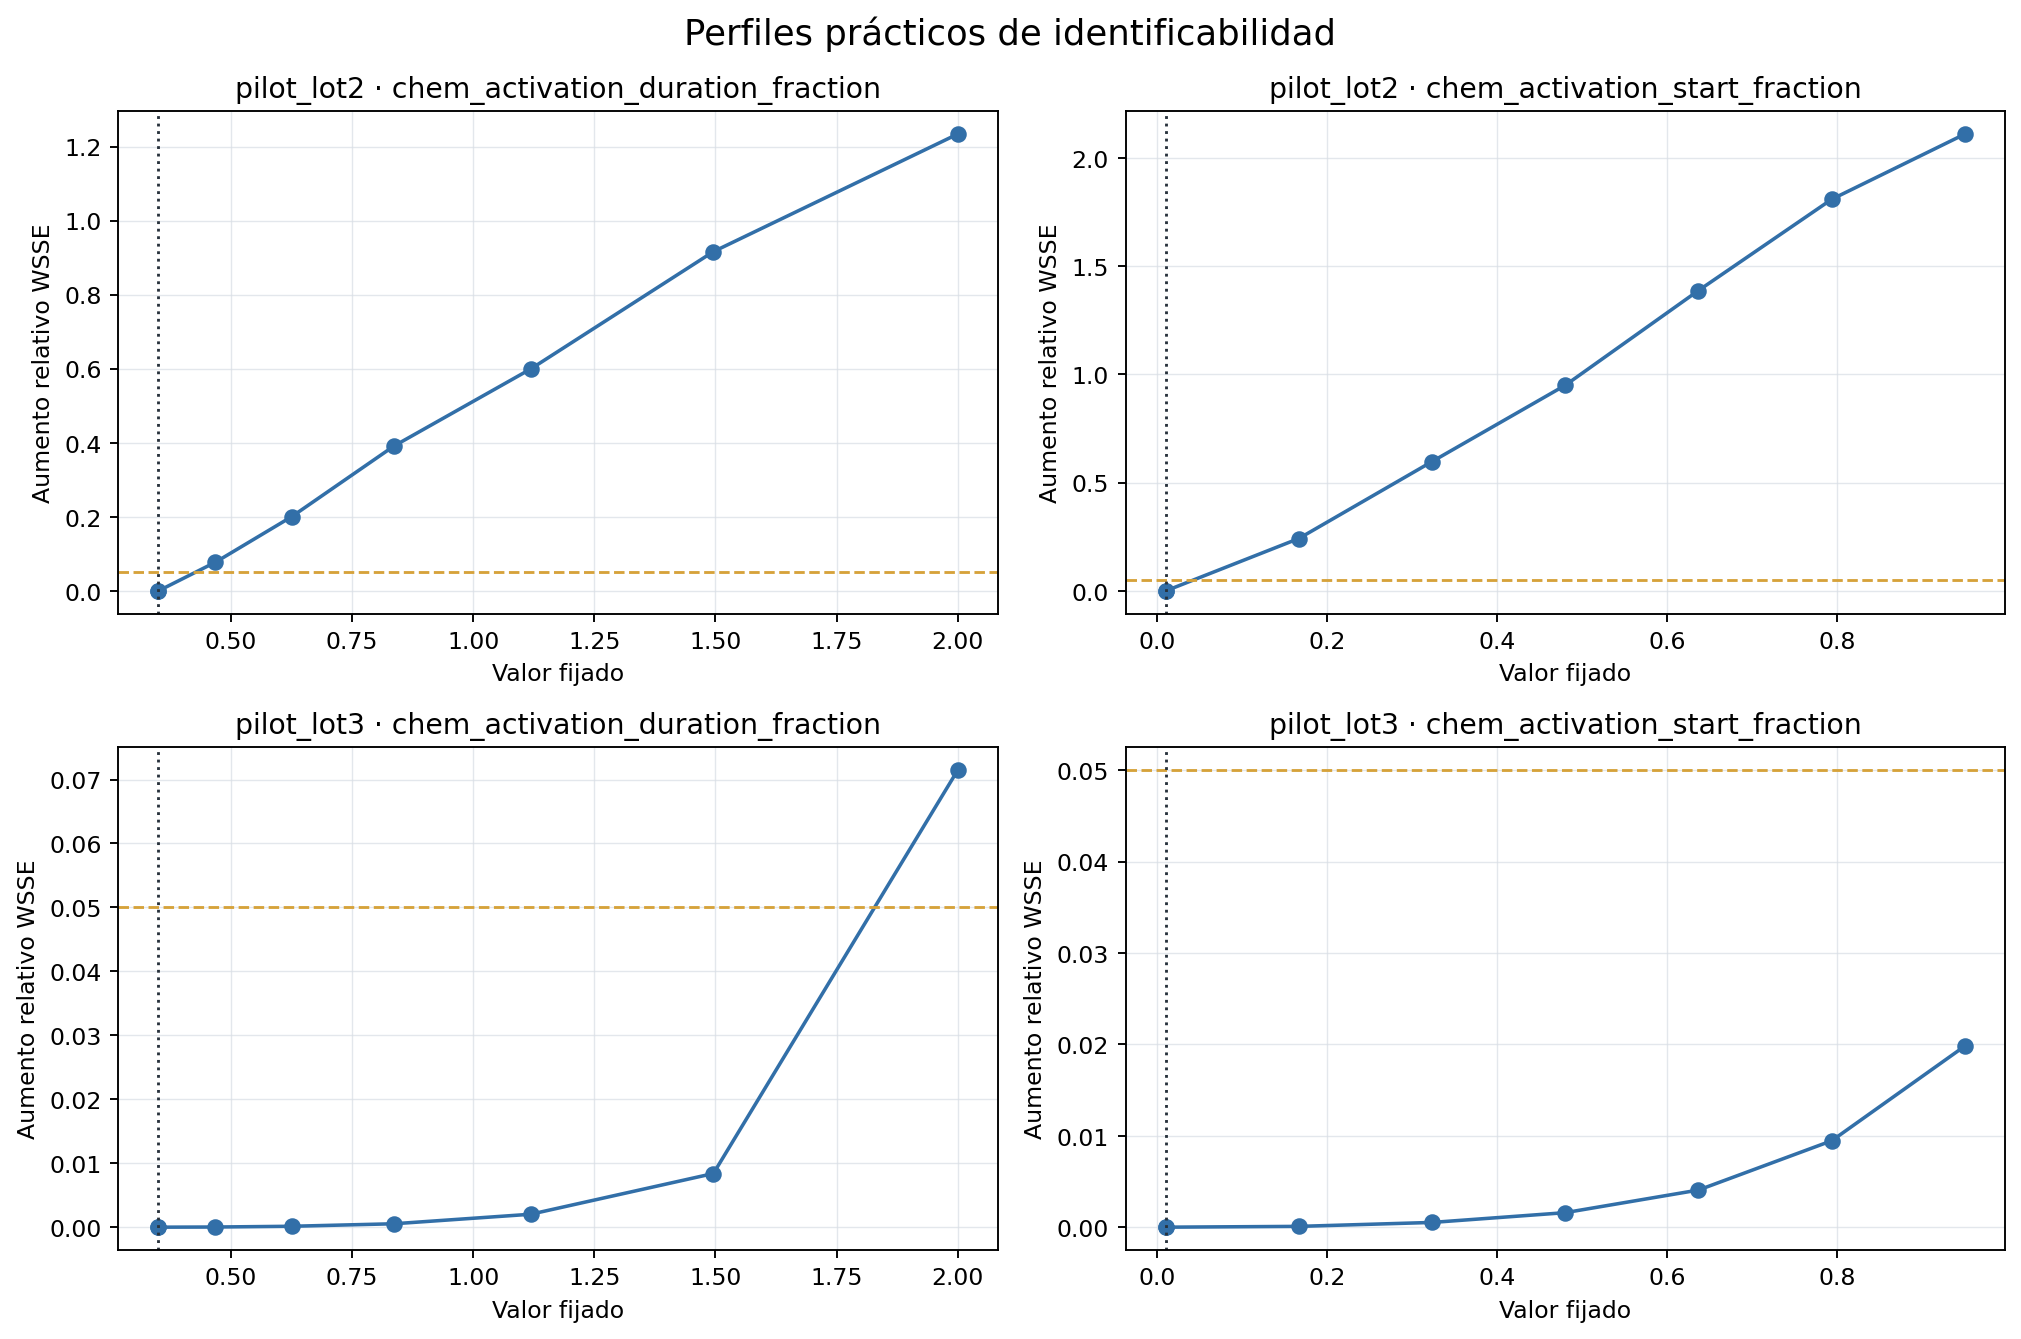

In [8]:
display(result["jacobian"].round(5))
display(result["loo_summary"].round(5))
activation_corr = result["local_correlations"].query(
    "parameter_1 == 'chem_activation_start_fraction' and parameter_2 == 'chem_activation_duration_fraction'"
)
display(activation_corr.round(5))
display(Image(filename=analysis.FIGURE_DIR / "activation_identifiability_profiles.png"))

## Transferencia entre escalas y cobertura auxiliar

,transfer_direction,calibration_matrix,target_matrix,batch,role,rmse_g_l_h,onset_delay_h
0,laboratory_natural_to_pilot,laboratory_natural_fit,pilot_lot2,26157,pilot_context,0.2699,2.9600
1,laboratory_natural_to_pilot,laboratory_natural_fit,pilot_lot2,26158,pilot_holdout,0.2263,5.8318
2,laboratory_natural_to_pilot,laboratory_natural_fit,pilot_lot2,26159,pilot_context,0.2247,21.5997
3,laboratory_natural_to_pilot,laboratory_natural_fit,pilot_lot3,26210,pilot_context,0.2317,18.9593
4,laboratory_natural_to_pilot,laboratory_natural_fit,pilot_lot3,26211,pilot_holdout,0.2614,23.7033
5,laboratory_natural_to_pilot,laboratory_natural_fit,pilot_lot3,26212,pilot_context,0.3432,20.4797
6,laboratory_synthetic_to_pilot,laboratory_synthetic_fit,pilot_lot2,26157,pilot_context,0.1222,0.1271
7,laboratory_synthetic_to_pilot,laboratory_synthetic_fit,pilot_lot2,26158,pilot_holdout,0.0956,3.8409
8,laboratory_synthetic_to_pilot,laboratory_synthetic_fit,pilot_lot2,26159,pilot_context,0.1580,5.8019
9,laboratory_synthetic_to_pilot,laboratory_synthetic_fit,pilot_lot3,26210,pilot_context,0.2288,24.3695


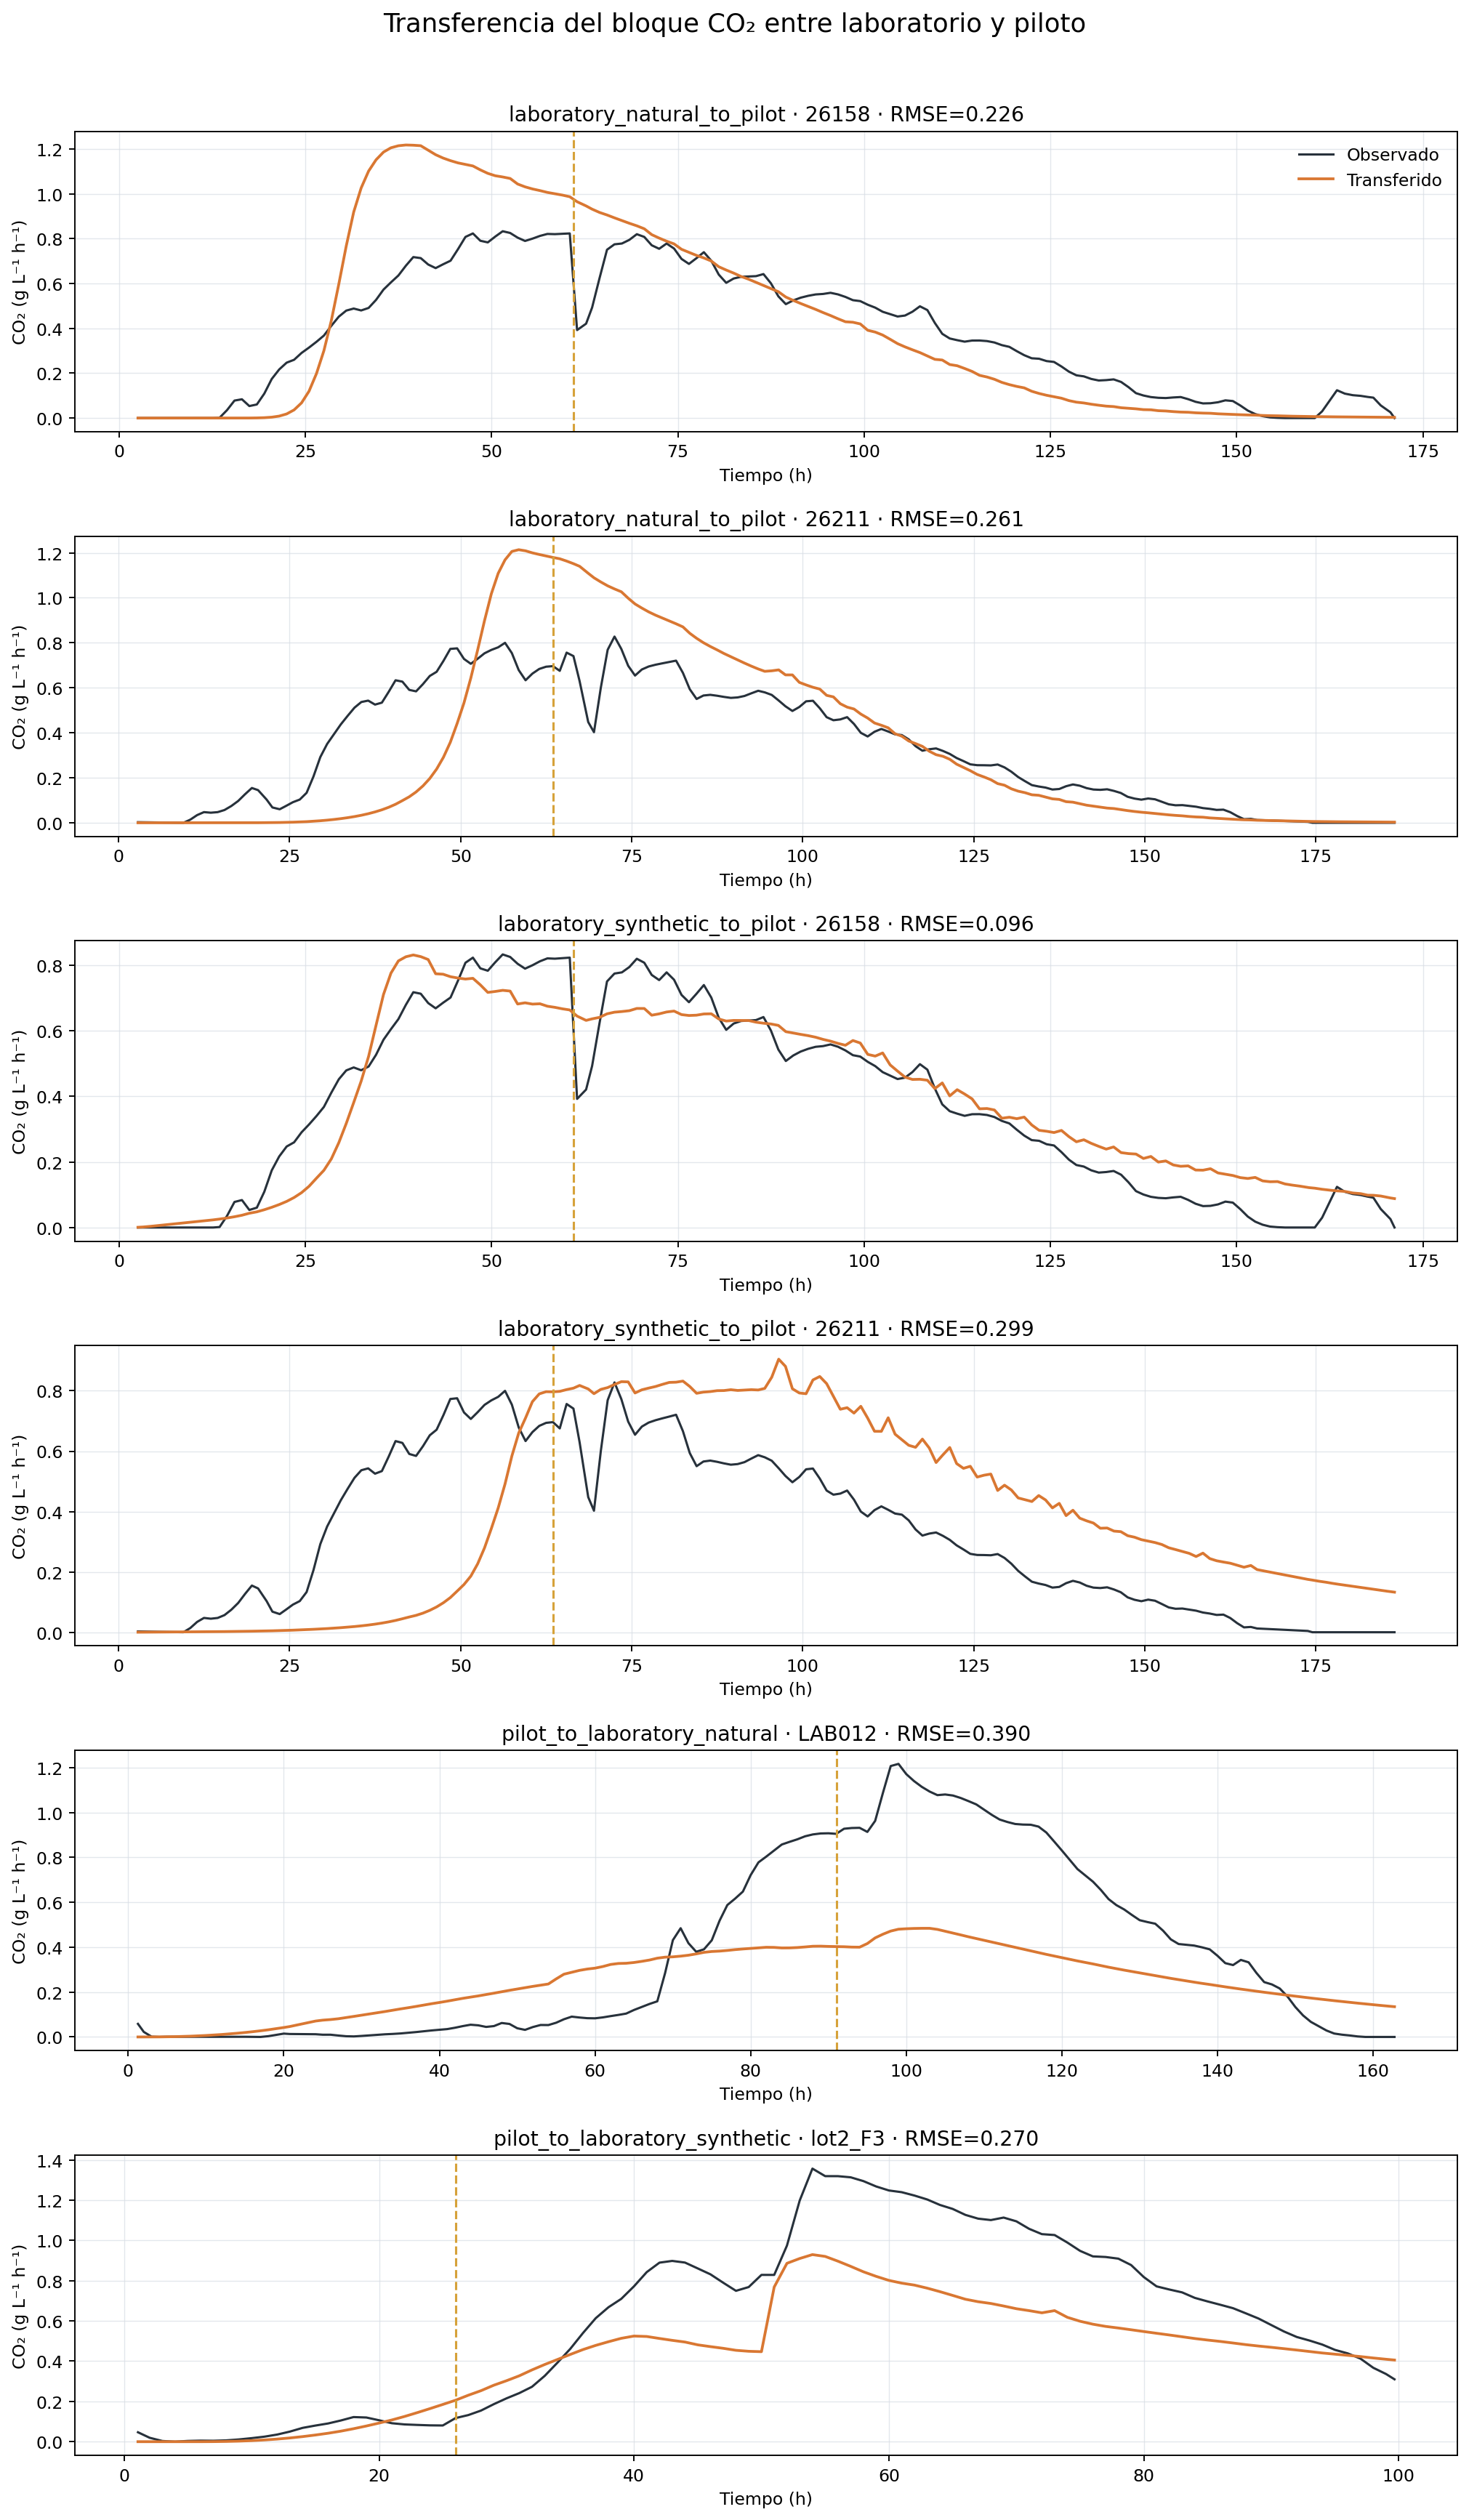

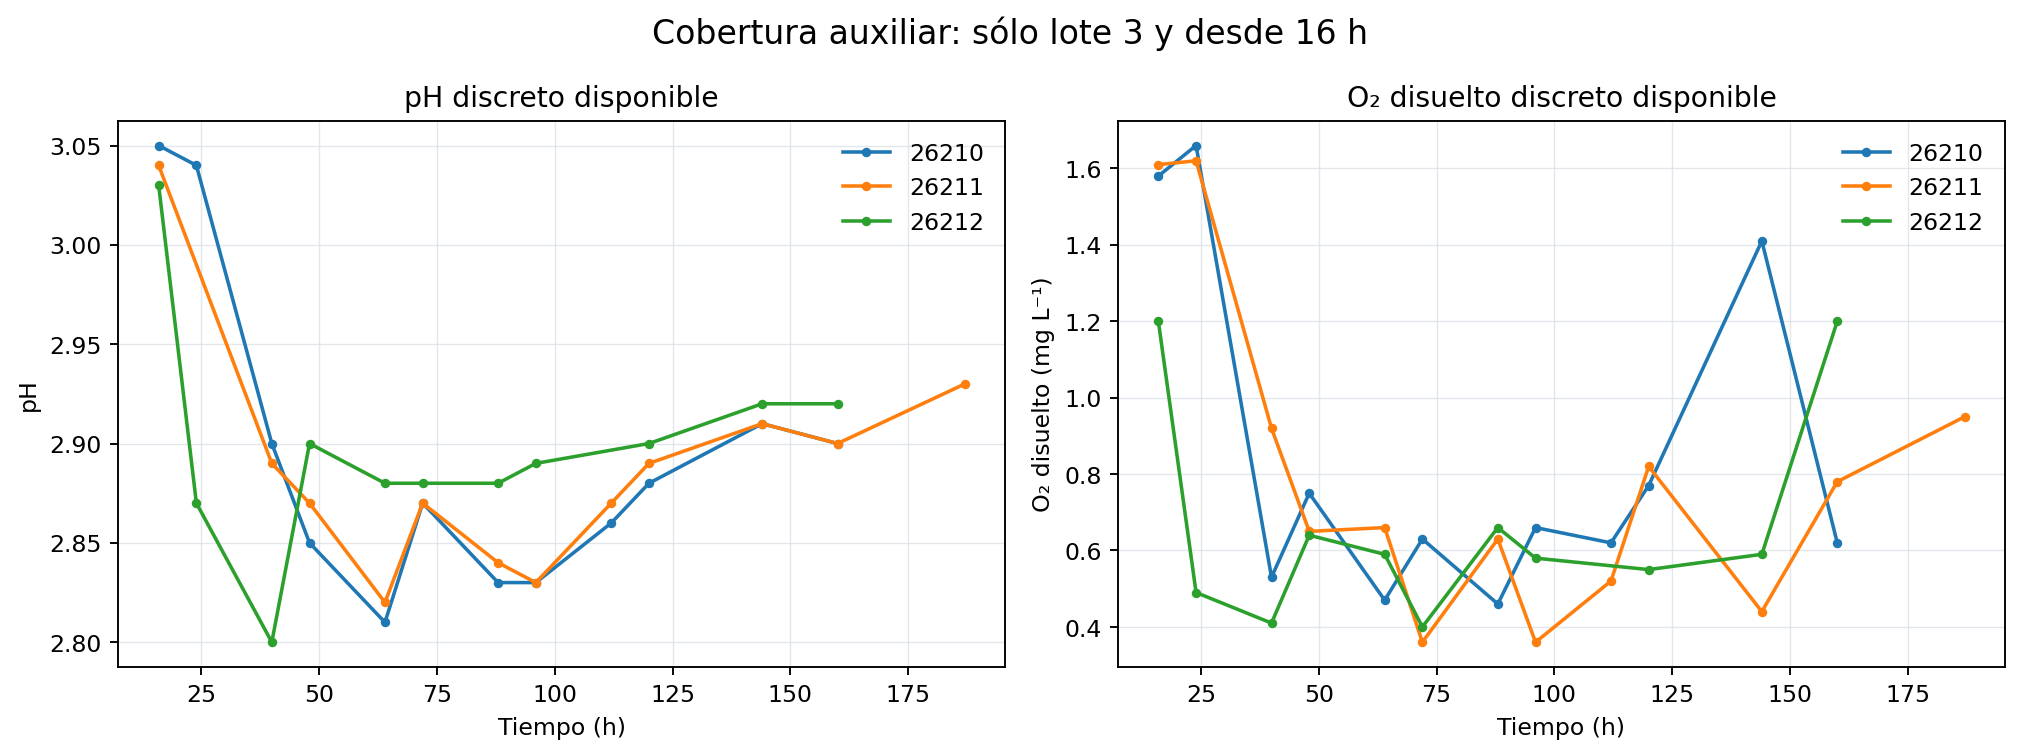

In [9]:
display(result["cross_scale_metrics"][[
    "transfer_direction", "calibration_matrix", "target_matrix", "batch", "role", "rmse_g_l_h", "onset_delay_h"
]].round(4))
display(Image(filename=analysis.FIGURE_DIR / "cross_scale_transfer.png"))
display(Image(filename=analysis.FIGURE_DIR / "ph_do_availability.png"))

## Takeaways

La validación cruzada entre lotes prueba si el bloque de liberación/observación CO₂ es estable frente a cambios de lote y programa térmico. La transferencia laboratorio↔piloto evalúa el mismo bloque condicionalmente a los drivers upstream específicos de cada escala.

Los diagnósticos de Jacobiano, perfiles y leave-one-batch-out deben interpretarse con cautela: cada calibración por lote utiliza sólo dos fermentaciones después de reservar el holdout. Esta reproducción no transforma los ceros artificiales en evidencia de ausencia de fermentación y no usa el pH/O₂ tardío para localizar el inicio.

In [10]:
print("Notebook ejecutado sin errores.")
print("Figuras:", len(list(analysis.FIGURE_DIR.glob("*.png"))))
print("Cross-scale:", result["manifest"]["cross_scale_status"])
print("Artefactos:", analysis.RESULTS_DIR.relative_to(ROOT))

Notebook ejecutado sin errores.
Figuras: 12
Cross-scale: both_directions_completed
Artefactos: fermentation_model\pilot_2026\results\co2_solubility_cross_lot_validation_2026
